# PROYECTO FINAL
## Sistema Inteligente de Prediccion, Segmentacion y Recomendacion

# FASE 1: Comprension del problema

## 1.1 Problema empresarial
SmartLife es una empresa de comercio electronico que cuenta con informacion
de sus clientes, como sus compras, gustos, tiempo que pasan en la plataforma,
productos que revisan y forma en la que usan el sistema.

El problema es que la empresa tiene muchos datos, pero necesita aprovecharlos
para entender mejor a sus clientes y tomar mejores decisiones.

Por esta razon, se busca crear un sistema que permita saber que clientes
podrian volver a comprar, que tipos de clientes existen y que productos
se pueden recomendar a cada uno.

## 1.2 Contexto

La empresa cuenta con datos historicos de sus usuarios y productos.

Entre estos datos se encuentra informacion sobre la edad de los usuarios,
cantidad de sesiones, compras realizadas, gasto promedio, productos vistos,
productos favoritos, satisfaccion, gustos e interacciones con productos.

Actualmente esta informacion puede ser usada para conocer mejor el
comportamiento de los clientes.

El proyecto busca usar estos datos para obtener resultados que ayuden
a la empresa en la toma de decisiones.

## 1.3 Usuarios beneficiarios

Los principales beneficiarios del sistema seran:

- El area de ventas, porque podra conocer que clientes tienen mayor
  posibilidad de realizar una nueva compra.

- El area de marketing, porque podra conocer diferentes grupos de clientes
  y realizar acciones diferentes para cada grupo.

- Los encargados de la plataforma, porque podran mostrar productos que
  tengan mayor relacion con los gustos de cada usuario.

- Los clientes, porque podran recibir recomendaciones de productos que
  tengan mayor relacion con sus intereses.

## 1.4 Objetivo del sistema

Crear un sistema inteligente que use la informacion de los clientes
para cumplir tres objetivos principales:

1. Predecir si un cliente realizara una compra durante los proximos 30 dias.

2. Encontrar diferentes grupos de clientes segun su comportamiento.

3. Recomendar productos de acuerdo con los gustos e interacciones
   de cada usuario.

## 1.5 Preguntas de negocio

El proyecto busca responder las siguientes preguntas:

### Pregunta 1 - Prediccion

¿Es posible saber si un cliente realizara una compra durante los
proximos 30 dias usando su informacion y comportamiento anterior?

### Pregunta 2 - Grupos de clientes

¿Que tipos de clientes existen segun su comportamiento dentro de
la plataforma?


### Pregunta 3 - Recomendacion

¿Que productos se pueden recomendar a cada cliente tomando en cuenta
sus gustos e interacciones anteriores?


## 1.6 Variables disponibles

Para realizar el proyecto se cuenta con informacion relacionada con:

- Edad del usuario.
- Tiempo que lleva usando la plataforma.
- Cantidad de sesiones.
- Tiempo promedio por sesion.
- Productos vistos.
- Productos favoritos.
- Compras realizadas anteriormente.
- Gasto promedio.
- Uso de descuentos.
- Interacciones con recomendaciones.
- Dias desde la ultima compra.
- Satisfaccion.
- Canal preferido.
- Categoria favorita.
- Dispositivo principal.
- Comportamiento del usuario.
- Informacion de los productos.
- Interacciones entre usuarios y productos.


## 1.7 Variable objetivo

Para la parte de prediccion se utilizara la variable:

```txt
realizara_compra_30d
```

Esta variable indica si el usuario realizara una compra durante los
proximos 30 dias.

- 0 = No realizara una compra.
- 1 = Si realizara una compra.

Para la parte de grupos de clientes no existe una variable objetivo,
ya que los grupos seran encontrados usando el comportamiento de los usuarios.

Para la parte de recomendaciones se utilizaran las interacciones entre
usuarios y productos para encontrar productos que puedan interesar a cada cliente.

# Fase 2: Dataset

Para realizar el proyecto se utilizaran cuatro archivos con datos sinteticos que han sido proporcionados para el desarrollo de este proyecto.
Los archivos utilizados son:

- usuarios_prediccion.csv
- perfil_comportamiento.csv
- catalogo_productos.csv
- interacciones_usuario_producto.csv

## 2.1 Cargar los archivos y librerias

In [233]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [235]:
df_prediccion = pd.read_csv("/content/drive/MyDrive/MAESTRIA MIADAS/MODULO 4 - MINERIA DE DATOS/PROYECTO-FINAL/usuarios_prediccion.csv")
df_perfil = pd.read_csv("/content/drive/MyDrive/MAESTRIA MIADAS/MODULO 4 - MINERIA DE DATOS/PROYECTO-FINAL/perfil_comportamiento.csv")
df_productos = pd.read_csv("/content/drive/MyDrive/MAESTRIA MIADAS/MODULO 4 - MINERIA DE DATOS/PROYECTO-FINAL/catalogo_productos.csv")
df_interacciones = pd.read_csv("/content/drive/MyDrive/MAESTRIA MIADAS/MODULO 4 - MINERIA DE DATOS/PROYECTO-FINAL/interacciones_usuario_producto.csv")

## 2.2 Cantidad de datos

Se reviso la cantidad de filas y columnas de cada archivo para conocer
el tamaño de los datos que se utilizaran durante el proyecto.

## 2.1 Cargar los archivos y librerias

## Justificacion de los datos

Los datos sinteticos fueron utilizados porque fueron proporcionados para
fines educativos y contienen informacion suficiente para realizar
prediccion, grupos de clientes y recomendaciones.

Ademas, incluyen datos vacios, filas repetidas y valores alejados,
lo que permite realizar las diferentes etapas de limpieza y analisis.

In [236]:
print("Prediccion:", df_prediccion.shape)
print("Perfil:", df_perfil.shape)
print("Productos:", df_productos.shape)
print("Interacciones:", df_interacciones.shape)

Prediccion: (2030, 17)
Perfil: (2025, 13)
Productos: (510, 7)
Interacciones: (30737, 11)


In [237]:
df_prediccion.head()

,id_usuario,edad,antiguedad_meses,sesiones_mes,minutos_promedio_sesion,productos_vistos,productos_favoritos,compras_ultimos_6m,gasto_promedio,descuento_utilizado,interacciones_recomendaciones,dias_desde_ultima_compra,satisfaccion,canal_preferido,categoria_favorita,dispositivo_principal,realizara_compra_30d
0,1001,38,16,13,32.4,31,3.0,5,38.90,7.1,10,21,9.4,App,Tecnología,Android,1
1,1002,24,29,14,36.2,37,4.0,3,125.21,20.2,5,44,8.6,App,Deporte,Android,0
2,1003,43,20,14,23.0,35,4.0,3,51.44,38.8,10,23,6.2,Web,Tecnología,Android,0
3,1004,45,44,10,28.1,44,7.0,3,71.44,32.3,3,52,7.0,App,Moda,Android,0
4,1005,18,8,7,10.4,39,8.0,5,216.19,56.2,5,43,4.5,App,Hogar,Android,0


## 2.3 Ver las columnas

Ahora queremos saber que informacion tiene cada archivo.

In [238]:
df_prediccion.columns

Index(['id_usuario', 'edad', 'antiguedad_meses', 'sesiones_mes',
       'minutos_promedio_sesion', 'productos_vistos', 'productos_favoritos',
       'compras_ultimos_6m', 'gasto_promedio', 'descuento_utilizado',
       'interacciones_recomendaciones', 'dias_desde_ultima_compra',
       'satisfaccion', 'canal_preferido', 'categoria_favorita',
       'dispositivo_principal', 'realizara_compra_30d'],
      dtype='object')

In [239]:
df_perfil.columns

Index(['id_usuario', 'frecuencia_sesiones', 'tiempo_plataforma',
       'diversidad_categorias', 'compras_mensuales', 'gasto_mensual',
       'sensibilidad_descuento', 'interaccion_recomendaciones',
       'productos_guardados', 'resenas_realizadas', 'devoluciones',
       'exploracion_novedades', 'fidelidad'],
      dtype='object')

In [240]:
df_productos.columns

Index(['id_producto', 'categoria', 'subcategoria', 'precio', 'nivel_novedad',
       'popularidad', 'sostenibilidad'],
      dtype='object')

In [241]:
df_interacciones.columns

Index(['id_usuario', 'id_producto', 'categoria', 'subcategoria', 'precio',
       'nivel_novedad', 'popularidad', 'tipo_interaccion', 'valoracion',
       'tiempo_interaccion_seg', 'compra'],
      dtype='object')

### 2.4 Ver las primeras filas

In [242]:
df_prediccion.head()

,id_usuario,edad,antiguedad_meses,sesiones_mes,minutos_promedio_sesion,productos_vistos,productos_favoritos,compras_ultimos_6m,gasto_promedio,descuento_utilizado,interacciones_recomendaciones,dias_desde_ultima_compra,satisfaccion,canal_preferido,categoria_favorita,dispositivo_principal,realizara_compra_30d
0,1001,38,16,13,32.4,31,3.0,5,38.90,7.1,10,21,9.4,App,Tecnología,Android,1
1,1002,24,29,14,36.2,37,4.0,3,125.21,20.2,5,44,8.6,App,Deporte,Android,0
2,1003,43,20,14,23.0,35,4.0,3,51.44,38.8,10,23,6.2,Web,Tecnología,Android,0
3,1004,45,44,10,28.1,44,7.0,3,71.44,32.3,3,52,7.0,App,Moda,Android,0
4,1005,18,8,7,10.4,39,8.0,5,216.19,56.2,5,43,4.5,App,Hogar,Android,0


In [243]:
df_perfil.head()

,id_usuario,frecuencia_sesiones,tiempo_plataforma,diversidad_categorias,compras_mensuales,gasto_mensual,sensibilidad_descuento,interaccion_recomendaciones,productos_guardados,resenas_realizadas,devoluciones,exploracion_novedades,fidelidad
0,1001,25.200000,342.4,1,8.80,249.424,51.400000,3.0,6,0,0,97.4,64.440
1,1002,19.800000,249.4,2,2.20,164.024,45.900000,5.0,6,3,0,91.0,64.560
2,1003,5.600000,313.1,1,1.05,130.824,92.900000,9.0,8,1,3,32.0,38.805
3,1004,27.000000,267.3,1,2.20,301.840,27.600000,12.0,10,3,2,40.1,81.000
4,1005,16.323657,252.4,2,3.00,132.180,89.291857,12.0,5,2,0,88.2,68.200


In [244]:
df_productos.head()

,id_producto,categoria,subcategoria,precio,nivel_novedad,popularidad,sostenibilidad
0,P001,Hogar,Cocina,42.72,80.3,58.6,56.4
1,P002,Deporte,Yoga,18.81,92.9,29.2,80.9
2,P003,Hogar,Organización,30.92,44.0,49.7,42.3
3,P004,Bienestar,Salud,61.86,75.7,64.7,51.2
4,P005,Tecnología,Accesorios,71.84,57.0,52.7,77.0


In [245]:
df_interacciones.head()

,id_usuario,id_producto,categoria,subcategoria,precio,nivel_novedad,popularidad,tipo_interaccion,valoracion,tiempo_interaccion_seg,compra
0,2533,P397,Hogar,Cocina,233.17,49.3,97.1,click,0.0,69.4,0
1,2887,P278,Hogar,Cocina,93.18,66.7,46.1,click,0.0,91.6,0
2,1146,P494,Moda,Casual,229.78,63.9,59.8,click,0.0,36.3,0
3,1228,P119,Deporte,Fitness,170.50,99.3,94.2,vista,1.0,296.4,0
4,2149,P117,Deporte,Yoga,90.89,28.9,79.7,click,0.0,299.2,0


## 2.5 Variables numericas y de categoria

Ahora se revisara que columnas contienen numeros y que columnas contienen
datos de categoria o texto.

Esta separacion sera importante mas adelante, ya que los datos numericos
y los datos de categoria no siempre se trabajan de la misma forma.

In [246]:
numericas_prediccion = df_prediccion.select_dtypes(include="number").columns
categorias_prediccion = df_prediccion.select_dtypes(exclude="number").columns

print("Variables numericas:")
print(numericas_prediccion)

print("\nVariables de categoria:")
print(categorias_prediccion)

Variables numericas:
Index(['id_usuario', 'edad', 'antiguedad_meses', 'sesiones_mes',
       'minutos_promedio_sesion', 'productos_vistos', 'productos_favoritos',
       'compras_ultimos_6m', 'gasto_promedio', 'descuento_utilizado',
       'interacciones_recomendaciones', 'dias_desde_ultima_compra',
       'satisfaccion', 'realizara_compra_30d'],
      dtype='object')

Variables de categoria:
Index(['canal_preferido', 'categoria_favorita', 'dispositivo_principal'], dtype='object')


In [247]:
numericas_perfil = df_perfil.select_dtypes(include="number").columns
categorias_perfil = df_perfil.select_dtypes(exclude="number").columns

print("Variables numericas:")
print(numericas_perfil)

print("\nVariables de categoria:")
print(categorias_perfil)

Variables numericas:
Index(['id_usuario', 'frecuencia_sesiones', 'tiempo_plataforma',
       'diversidad_categorias', 'compras_mensuales', 'gasto_mensual',
       'sensibilidad_descuento', 'interaccion_recomendaciones',
       'productos_guardados', 'resenas_realizadas', 'devoluciones',
       'exploracion_novedades', 'fidelidad'],
      dtype='object')

Variables de categoria:
Index([], dtype='object')


In [248]:
numericas_productos = df_productos.select_dtypes(include="number").columns
categorias_productos = df_productos.select_dtypes(exclude="number").columns

print("Variables numericas:")
print(numericas_productos)

print("\nVariables de categoria:")
print(categorias_productos)

Variables numericas:
Index(['precio', 'nivel_novedad', 'popularidad', 'sostenibilidad'], dtype='object')

Variables de categoria:
Index(['id_producto', 'categoria', 'subcategoria'], dtype='object')


In [249]:
numericas_interacciones = df_interacciones.select_dtypes(include="number").columns
categorias_interacciones = df_interacciones.select_dtypes(exclude="number").columns

print("Variables numericas:")
print(numericas_interacciones)

print("\nVariables de categoria:")
print(categorias_interacciones)

Variables numericas:
Index(['id_usuario', 'precio', 'nivel_novedad', 'popularidad', 'valoracion',
       'tiempo_interaccion_seg', 'compra'],
      dtype='object')

Variables de categoria:
Index(['id_producto', 'categoria', 'subcategoria', 'tipo_interaccion'], dtype='object')


## 2.6 Variable objetivo

Para la parte de prediccion se utilizara como variable objetivo:

**realizara_compra_30d**

Esta variable indica si el usuario realizara una compra durante los
proximos 30 dias.

- 0 = El usuario no realizara una compra.
- 1 = El usuario si realizara una compra.

El archivo perfil_comportamiento.csv no tiene una variable objetivo,
porque sera utilizado para encontrar grupos de clientes segun su comportamiento.

Para la parte de recomendaciones se utilizaran principalmente las
interacciones entre usuarios y productos.

## 2.7 Revision de datos vacios

Ahora se revisara si existen datos vacios en cada uno de los archivos.

En esta parte solamente se contaran los datos vacios.

Todavia no se eliminaran ni se reemplazaran, ya que primero se quiere
conocer el estado original de los datos.

In [250]:
print("PREDICCION")
print(df_prediccion.isnull().sum())

PREDICCION
id_usuario                        0
edad                              0
antiguedad_meses                  0
sesiones_mes                      0
minutos_promedio_sesion           0
productos_vistos                  0
productos_favoritos              30
compras_ultimos_6m                0
gasto_promedio                   40
descuento_utilizado               0
interacciones_recomendaciones     0
dias_desde_ultima_compra          0
satisfaccion                     51
canal_preferido                  30
categoria_favorita                0
dispositivo_principal             0
realizara_compra_30d              0
dtype: int64


In [251]:
print("PERFIL")
print(df_perfil.isnull().sum())

PERFIL
id_usuario                      0
frecuencia_sesiones             0
tiempo_plataforma              41
diversidad_categorias           0
compras_mensuales               0
gasto_mensual                   0
sensibilidad_descuento         40
interaccion_recomendaciones     0
productos_guardados             0
resenas_realizadas              0
devoluciones                    0
exploracion_novedades           0
fidelidad                      31
dtype: int64


In [252]:
print("PRODUCTOS")
print(df_productos.isnull().sum())

PRODUCTOS
id_producto       0
categoria         0
subcategoria      0
precio            0
nivel_novedad     8
popularidad       9
sostenibilidad    0
dtype: int64


In [253]:
print("INTERACCIONES")
print(df_interacciones.isnull().sum())

INTERACCIONES
id_usuario                  0
id_producto                 0
categoria                 245
subcategoria                0
precio                    308
nivel_novedad             495
popularidad               541
tipo_interaccion            0
valoracion                460
tiempo_interaccion_seg    369
compra                      0
dtype: int64


## 2.8 Revision de filas repetidas

Tambien se revisara si existen filas completamente repetidas dentro
de cada archivo.

En esta parte solamente se contaran.

La eliminacion de estas filas se realizara mas adelante durante
la preparacion de los datos.

In [254]:
print("Prediccion:", df_prediccion.duplicated().sum())
print("Perfil:", df_perfil.duplicated().sum())
print("Productos:", df_productos.duplicated().sum())
print("Interacciones:", df_interacciones.duplicated().sum())

Prediccion: 30
Perfil: 25
Productos: 10
Interacciones: 684


## 2.9 Resumen general de los archivos

Para tener una vista mas clara de los datos, se realizara una tabla
con la cantidad de filas, columnas, datos vacios y filas repetidas
de cada archivo.

In [255]:
resumen = pd.DataFrame({
    "Archivo": [
        "usuarios_prediccion",
        "perfil_comportamiento",
        "catalogo_productos",
        "interacciones_usuario_producto"
    ],
    "Filas": [
        df_prediccion.shape[0],
        df_perfil.shape[0],
        df_productos.shape[0],
        df_interacciones.shape[0]
    ],
    "Columnas": [
        df_prediccion.shape[1],
        df_perfil.shape[1],
        df_productos.shape[1],
        df_interacciones.shape[1]
    ],
    "Nulos": [
        df_prediccion.isnull().sum().sum(),
        df_perfil.isnull().sum().sum(),
        df_productos.isnull().sum().sum(),
        df_interacciones.isnull().sum().sum()
    ],
    "Duplicados": [
        df_prediccion.duplicated().sum(),
        df_perfil.duplicated().sum(),
        df_productos.duplicated().sum(),
        df_interacciones.duplicated().sum()
    ]
})

display(resumen)

,Archivo,Filas,Columnas,Nulos,Duplicados
0,usuarios_prediccion,2030,17,151,30
1,perfil_comportamiento,2025,13,112,25
2,catalogo_productos,510,7,17,10
3,interacciones_usuario_producto,30737,11,2418,684


## 2.10 Durante esta primera revision se encontraron datos vacios y filas
repetidas en algunos de los archivos.

En esta fase solamente se esta revisando y documentando el estado
original de los datos.

La limpieza de los datos se realizara mas adelante, donde se decidira
que hacer con los valores vacios, filas repetidas y otros valores
que puedan afectar el analisis.

# FASE 3. Analisis exploratorio - EDA

En esta fase se revisaran los datos mediante graficos y comparaciones.

El objetivo es conocer mejor como se comportan las variables,
encontrar diferencias entre los usuarios y observar posibles relaciones
que puedan ser utiles mas adelante.

Primero se trabajara con el archivo usuarios_prediccion.csv.

## 3.1 Resumen de los datos numericos

Primero se revisaran algunos valores generales de las variables numericas,
como el promedio, valor minimo y valor maximo.

Esto ayudara a conocer mejor los datos antes de realizar los graficos.

In [256]:
df_prediccion.describe()

,id_usuario,edad,antiguedad_meses,sesiones_mes,minutos_promedio_sesion,productos_vistos,productos_favoritos,compras_ultimos_6m,gasto_promedio,descuento_utilizado,interacciones_recomendaciones,dias_desde_ultima_compra,satisfaccion,realizara_compra_30d
count,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2000.000000,2030.000000,1990.000000,2030.000000,2030.000000,2030.000000,1979.000000,2030.000000
mean,2003.500493,34.783251,25.262069,12.337438,21.734729,35.191626,5.030000,3.201478,88.234569,28.410246,8.015764,38.028571,7.255432,0.264532
std,577.089382,10.337685,15.746929,4.181789,7.852028,5.976727,2.290136,1.794328,67.508599,15.570128,2.888387,24.394898,1.389781,0.441192
min,1001.000000,18.000000,1.000000,2.000000,3.000000,16.000000,0.000000,0.000000,12.240000,0.200000,0.000000,1.000000,2.800000,0.000000
25%,1504.250000,27.000000,14.000000,10.000000,16.400000,31.000000,3.000000,2.000000,50.852500,16.100000,6.000000,21.000000,6.300000,0.000000
50%,2005.500000,35.000000,22.000000,12.000000,21.500000,35.000000,5.000000,3.000000,73.145000,26.500000,8.000000,32.000000,7.300000,0.000000
75%,2503.750000,42.000000,33.000000,14.000000,26.600000,39.000000,6.000000,4.000000,107.907500,38.775000,10.000000,49.000000,8.200000,1.000000
max,3000.000000,70.000000,96.000000,64.000000,55.200000,59.000000,15.000000,10.000000,1508.906939,90.700000,18.000000,163.000000,10.000000,1.000000


## 3.2 Histogramas

Se realizaran histogramas para observar como se distribuyen algunas
de las variables numericas.

Se revisaran la edad, cantidad de sesiones, gasto promedio,
compras anteriores y satisfaccion.

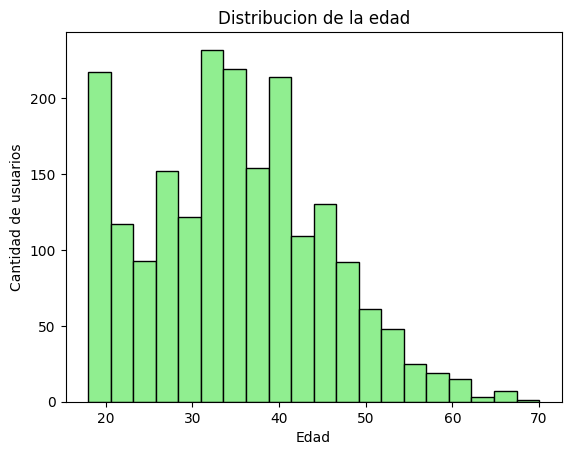

In [257]:
# Por edad
plt.hist(df_prediccion["edad"], bins=20, edgecolor="black", color='lightgreen')
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribucion de la edad")
plt.show()

### Interpretacion

La edad promedio de los usuarios es de aproximadamente 34.78 años y la
mediana es de 35 años.

La edad minima es de 18 años y la maxima de 70 años.

La mayor parte de los usuarios se concentra alrededor de edades medias,
principalmente entre 27 y 42 años.

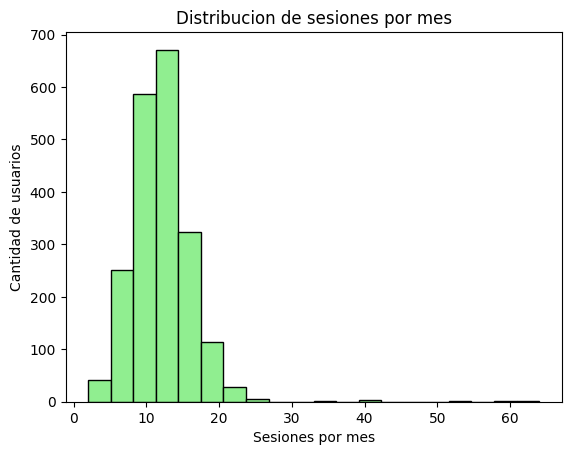

In [258]:
# Por mes
plt.hist(df_prediccion["sesiones_mes"], bins=20, edgecolor="black", color="lightgreen")
plt.xlabel("Sesiones por mes")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribucion de sesiones por mes")
plt.show()

### Interpretacion

Los usuarios realizan en promedio 12.34 sesiones por mes y la mediana
es de 12 sesiones.

La mayor parte de los usuarios se encuentra alrededor de 10 a 14 sesiones
por mes.

Tambien existen algunos usuarios con una cantidad de sesiones mucho mayor,
llegando hasta 64 sesiones.

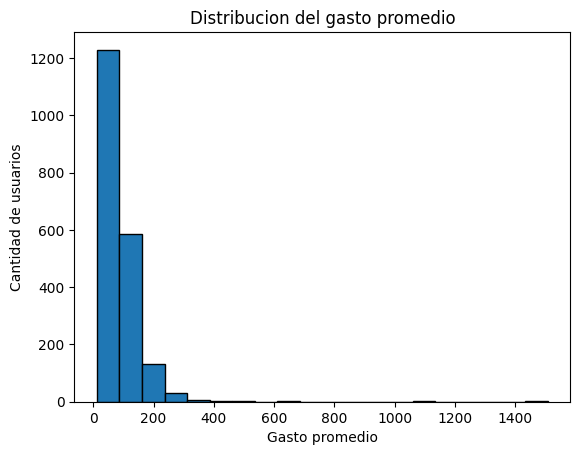

In [259]:
# Gasto promedio
plt.hist(df_prediccion["gasto_promedio"].dropna(), bins=20, edgecolor="black")
plt.xlabel("Gasto promedio")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribucion del gasto promedio")
plt.show()

### Interpretacion

El gasto promedio de los usuarios es de aproximadamente 88.23, mientras
que la mediana es de 73.15.

La diferencia entre el promedio y la mediana muestra que existen algunos
usuarios con gastos mucho mas altos que el resto.

El gasto minimo es de 12.24 y el valor maximo llega a 1508.91.

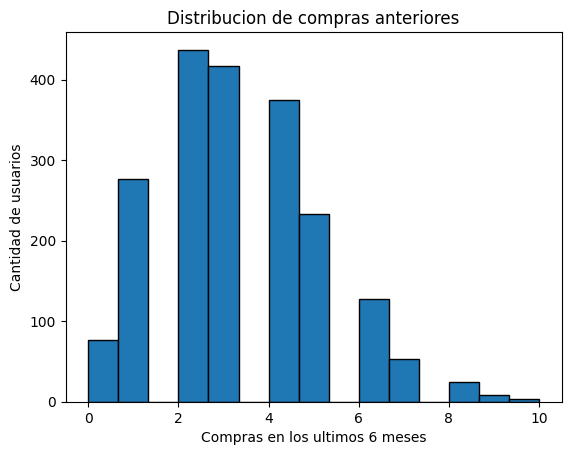

In [260]:
# Compras anteriores
plt.hist(df_prediccion["compras_ultimos_6m"], bins=15, edgecolor="black")
plt.xlabel("Compras en los ultimos 6 meses")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribucion de compras anteriores")
plt.show()

### Interpretacion

Los usuarios realizaron en promedio 3.20 compras durante los ultimos
6 meses.

La mediana es de 3 compras y la mayor parte de los usuarios tiene entre
2 y 4 compras.

El valor minimo es 0 y el maximo es 10 compras.

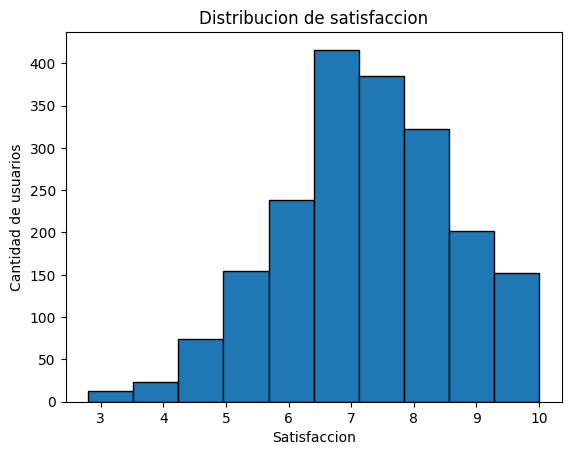

In [261]:
# Satisfaccion
plt.hist(df_prediccion["satisfaccion"].dropna(), bins=10, edgecolor="black")
plt.xlabel("Satisfaccion")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribucion de satisfaccion")
plt.show()

### Interpretacion

La satisfaccion promedio de los usuarios es de aproximadamente 7.26
y la mediana es de 7.3.

La mayor parte de los usuarios tiene valores de satisfaccion entre
6.3 y 8.2.

El valor minimo es 2.8 y el maximo es 10, por lo que en general se observa
un nivel de satisfaccion relativamente alto.

## 3.3 Boxplots

Ahora se utilizaran boxplots para observar la distribucion de algunas
variables y encontrar posibles valores muy alejados del resto.

Por el momento solamente se identificaran estos valores.
No seran eliminados en esta fase.

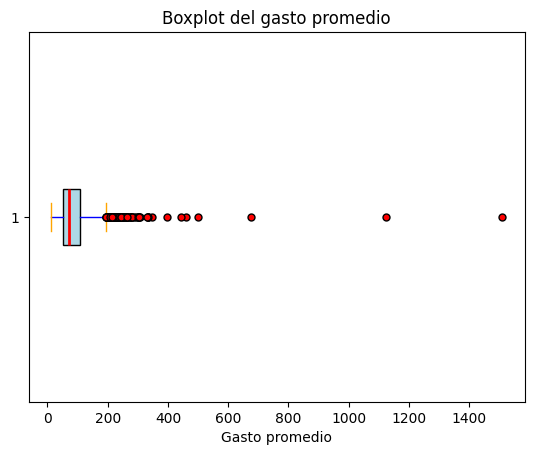

In [262]:
# Gasto promedio
plt.boxplot(df_prediccion["gasto_promedio"].dropna(), vert=False, boxprops={"facecolor": "lightblue"}, patch_artist=True, whiskerprops={"color": "blue"}, capprops={"color": "orange"}, medianprops={"color": "red", "linewidth": 2}, flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markersize": 5
    }
)
plt.xlabel("Gasto promedio")
plt.title("Boxplot del gasto promedio")
plt.show()

### Interpretacion

La mediana del gasto promedio es de 73.15.

La mitad de los usuarios tiene un gasto aproximadamente entre 50.85
y 107.91.

Tambien se observan varios valores bastante alejados del resto,
principalmente por encima de 193.49.

Estos valores deberan revisarse mas adelante antes de decidir si se
mantienen o se modifican.

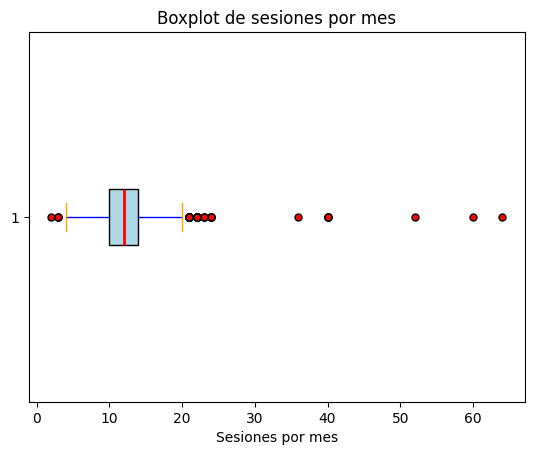

In [263]:
plt.boxplot(df_prediccion["sesiones_mes"].dropna(), vert=False, notch=False, boxprops={"facecolor": "lightblue"}, patch_artist=True, whiskerprops={"color": "blue"}, capprops={"color": "orange"}, medianprops={"color": "red", "linewidth": 2}, flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markersize": 5
    }
)
plt.xlabel("Sesiones por mes")
plt.title("Boxplot de sesiones por mes")
plt.show()

### Interpretacion

La mediana es de 12 sesiones por mes.

La mitad de los usuarios se encuentra aproximadamente entre 10 y
14 sesiones.

Se observan algunos valores alejados del resto, incluyendo usuarios
con mas de 20 sesiones y algunos valores bajos.

Estos casos se revisaran mas adelante durante la preparacion de los datos.

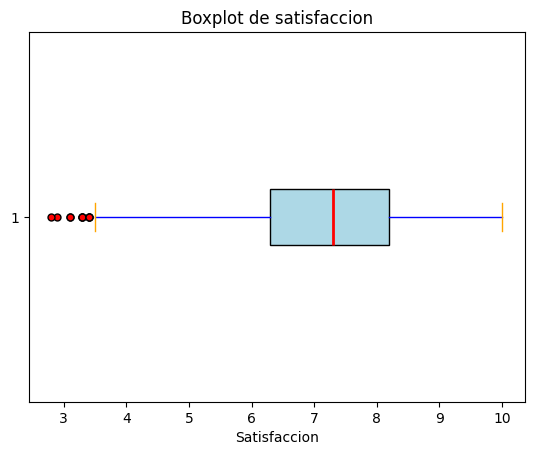

In [264]:
plt.boxplot(df_prediccion["satisfaccion"].dropna(), vert=False, notch=False, boxprops={"facecolor": "lightblue"}, patch_artist=True, whiskerprops={"color": "blue"}, capprops={"color": "orange"}, medianprops={"color": "red", "linewidth": 2}, flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markersize": 5
    }
)
plt.xlabel("Satisfaccion")
plt.title("Boxplot de satisfaccion")
plt.show()

### Interpretacion

La mediana de satisfaccion es de 7.3.

La mitad de los usuarios presenta valores aproximadamente entre 6.3 y 8.2.

Existen pocos valores bajos alejados del resto, principalmente por debajo
de aproximadamente 3.45.

En general, la satisfaccion se encuentra concentrada en valores medios
y altos.

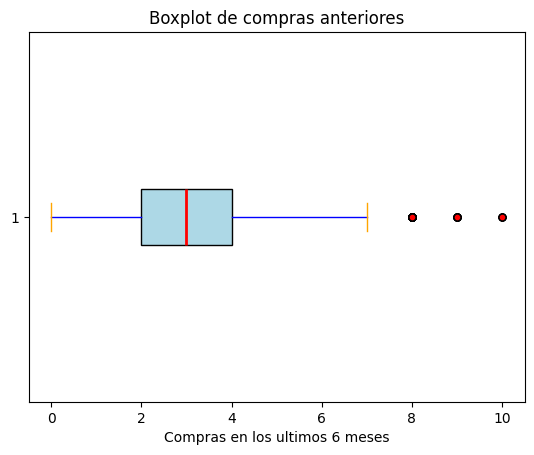

In [265]:
plt.boxplot(df_prediccion["compras_ultimos_6m"].dropna(), vert=False, notch=False, boxprops={"facecolor": "lightblue"}, patch_artist=True, whiskerprops={"color": "blue"}, capprops={"color": "orange"}, medianprops={"color": "red", "linewidth": 2}, flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markersize": 5
    }
)
plt.xlabel("Compras en los ultimos 6 meses")
plt.title("Boxplot de compras anteriores")
plt.show()

### Interpretacion

La mediana es de 3 compras durante los ultimos 6 meses.

La mitad de los usuarios se encuentra entre 2 y 4 compras.

Se observan algunos usuarios con una cantidad de compras mayor al resto,
principalmente entre 8 y 10 compras.

Estos valores se revisaran mas adelante para determinar si representan
casos normales o valores demasiado alejados.

## 3.4 Frecuencias

Ahora se revisara cuantas veces aparece cada opcion en algunas variables
de categoria.

Esto permitira conocer cuales son las opciones mas comunes entre los usuarios.

In [266]:
df_prediccion["canal_preferido"].value_counts()

,count
canal_preferido,
App,1125
Web,662
Tablet,213


In [267]:
df_prediccion["categoria_favorita"].value_counts()

,count
categoria_favorita,
Tecnología,572
Moda,400
Hogar,386
Deporte,348
Bienestar,324


In [268]:
df_prediccion["dispositivo_principal"].value_counts()

,count
dispositivo_principal,
Android,912
iOS,852
Web,266


In [269]:
df_prediccion["realizara_compra_30d"].value_counts()

,count
realizara_compra_30d,
0,1493
1,537


## 3.5 Compra durante los proximos 30 dias

Se revisara la cantidad de usuarios que realizaron o no una compra
durante los proximos 30 dias.

Esto permitira observar si existe una diferencia grande entre ambas opciones.

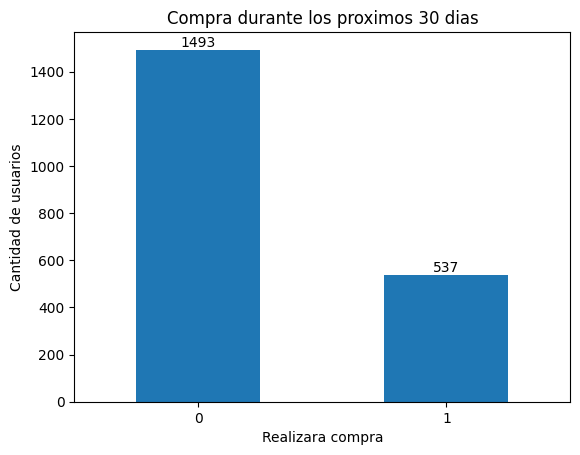

In [270]:
conteo_compra = df_prediccion["realizara_compra_30d"].value_counts().sort_index()

ax = conteo_compra.plot(kind="bar")

plt.xlabel("Realizara compra")
plt.ylabel("Cantidad de usuarios")
plt.title("Compra durante los proximos 30 dias")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0])

plt.show()

### Interpretacion

Se puede observar que existen mas usuarios que no realizaran una compra
en comparacion con los que si realizaran una compra.

Esto muestra que los dos grupos no tienen la misma cantidad de usuarios.

Esta diferencia debera tomarse en cuenta mas adelante cuando se cree
el modelo de prediccion.

## 3.6 Correlacion entre variables

## 3.6 Correlacion entre variables

Ahora se revisara si algunas variables tienen relacion entre ellas.

Tambien se observara cuales tienen mayor relacion con la variable
realizara_compra_30d.

Los valores cercanos a 1 indican que ambas variables tienden a aumentar
juntas.

Los valores cercanos a -1 indican que mientras una aumenta, la otra
tiende a disminuir.

Los valores cercanos a 0 indican que existe poca relacion.

In [271]:
import seaborn as sns

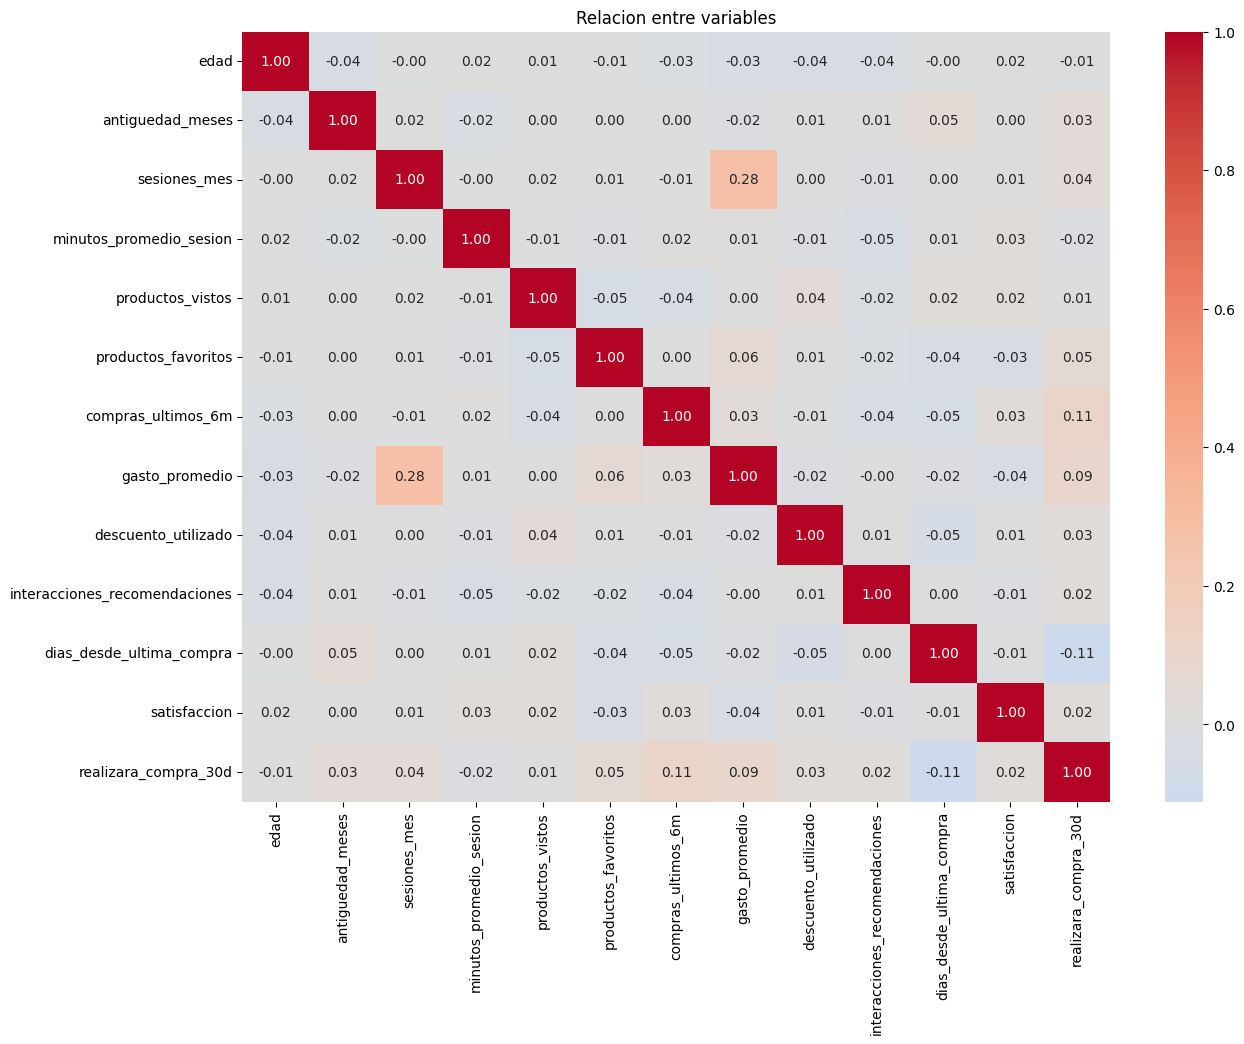

In [272]:
columnas_corr = [
    "edad",
    "antiguedad_meses",
    "sesiones_mes",
    "minutos_promedio_sesion",
    "productos_vistos",
    "productos_favoritos",
    "compras_ultimos_6m",
    "gasto_promedio",
    "descuento_utilizado",
    "interacciones_recomendaciones",
    "dias_desde_ultima_compra",
    "satisfaccion",
    "realizara_compra_30d"
]

correlacion = df_prediccion[columnas_corr].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Relacion entre variables")
plt.show()

### Interpretacion

La mayoria de las variables muestran una relacion baja con
realizara_compra_30d.

Las variables que muestran una mayor relacion son:

- compras_ultimos_6m con aproximadamente 0.11.
- gasto_promedio con aproximadamente 0.09.
- dias_desde_ultima_compra con aproximadamente -0.11.

Esto indica que los usuarios que realizaron mas compras anteriormente
y que tienen un gasto mayor tienden ligeramente a realizar una nueva compra.

Por otro lado, dias_desde_ultima_compra tiene una relacion negativa.
Esto indica que mientras mas dias pasan desde la ultima compra,
la posibilidad de realizar una nueva compra tiende a disminuir.

No se observa una sola variable que explique por si sola si el usuario
va a comprar, por lo que sera necesario utilizar varias variables juntas.

## 3.7 Comparacion entre usuarios que compran y no compran

Ahora se compararan algunas caracteristicas de los usuarios que realizan
una compra con los usuarios que no realizan una compra.

Esto permitira observar si existen diferencias entre ambos grupos.

In [273]:
comparacion_compra = df_prediccion.groupby("realizara_compra_30d")[
    [
        "compras_ultimos_6m",
        "gasto_promedio",
        "sesiones_mes",
        "dias_desde_ultima_compra",
        "satisfaccion"
    ]
].mean().round(2)

comparacion_compra

,compras_ultimos_6m,gasto_promedio,sesiones_mes,dias_desde_ultima_compra,satisfaccion
realizara_compra_30d,,,,,
0,3.08,84.45,12.24,39.66,7.24
1,3.54,98.78,12.60,33.49,7.31


### Compras realizadas anteriormente

Se comparara la cantidad promedio de compras realizadas durante los
ultimos 6 meses entre los usuarios que volveran a comprar y los que no.

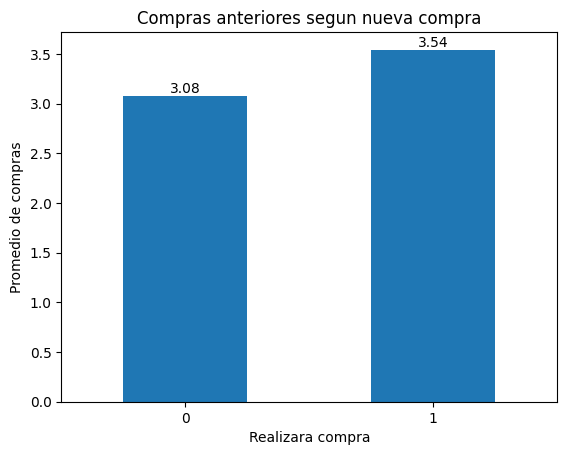

In [274]:
datos = df_prediccion.groupby("realizara_compra_30d")["compras_ultimos_6m"].mean()

ax = datos.plot(kind="bar")

plt.xlabel("Realizara compra")
plt.ylabel("Promedio de compras")
plt.title("Compras anteriores segun nueva compra")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt="%.2f")

plt.show()

### Interpretacion

Los usuarios que no realizaran una nueva compra tienen un promedio
de 3.08 compras durante los ultimos 6 meses.

Los usuarios que si realizaran una nueva compra tienen un promedio
de 3.54 compras.

Esto muestra que los usuarios que ya compraron mas veces anteriormente
tambien presentan una mayor tendencia a volver a comprar.

Por esta razon, la cantidad de compras anteriores puede ser una
informacion util para el modelo.

### Gasto promedio

Ahora se comparara el gasto promedio entre los usuarios que realizaran
una nueva compra y los que no.

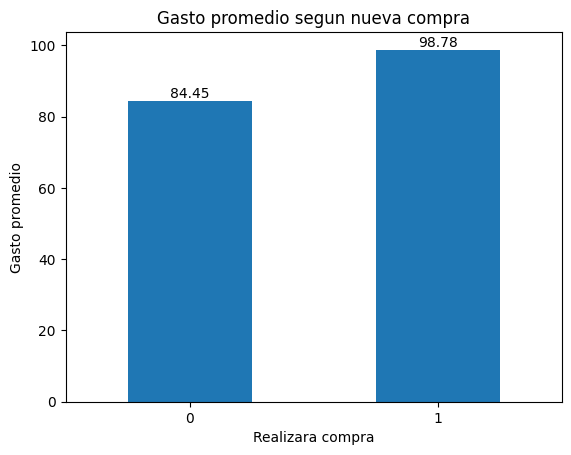

In [275]:
datos = df_prediccion.groupby("realizara_compra_30d")["gasto_promedio"].mean()

ax = datos.plot(kind="bar")

plt.xlabel("Realizara compra")
plt.ylabel("Gasto promedio")
plt.title("Gasto promedio segun nueva compra")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt="%.2f")

plt.show()

### Interpretacion

Los usuarios que no realizaran una compra tienen un gasto promedio
de aproximadamente 84.45.

Los usuarios que si realizaran una compra tienen un gasto promedio
de aproximadamente 98.78.

Existe una diferencia de aproximadamente 14.33 entre ambos grupos.

Esto muestra que los usuarios que suelen gastar mas tambien presentan
una mayor tendencia a realizar una nueva compra.

### Dias desde la ultima compra

Se comparara cuantos dias han pasado desde la ultima compra de los
usuarios que volveran a comprar y de los que no.

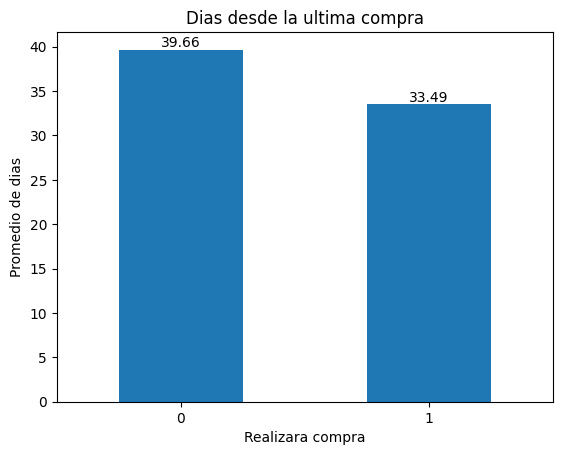

In [276]:
datos = df_prediccion.groupby("realizara_compra_30d")["dias_desde_ultima_compra"].mean()

ax = datos.plot(kind="bar")

plt.xlabel("Realizara compra")
plt.ylabel("Promedio de dias")
plt.title("Dias desde la ultima compra")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt="%.2f")

plt.show()

### Interpretacion

Los usuarios que no realizaran una nueva compra tienen en promedio
39.66 dias desde su ultima compra.

Los usuarios que si realizaran una nueva compra tienen en promedio
33.49 dias desde su ultima compra.

Esto muestra que los usuarios que compraron mas recientemente presentan
una mayor tendencia a volver a comprar.

Por esta razon, los dias desde la ultima compra pueden ser importantes
para realizar la prediccion.

### Sesiones por mes

Ahora se comparara la cantidad promedio de sesiones mensuales entre
los usuarios que realizaran una compra y los que no.

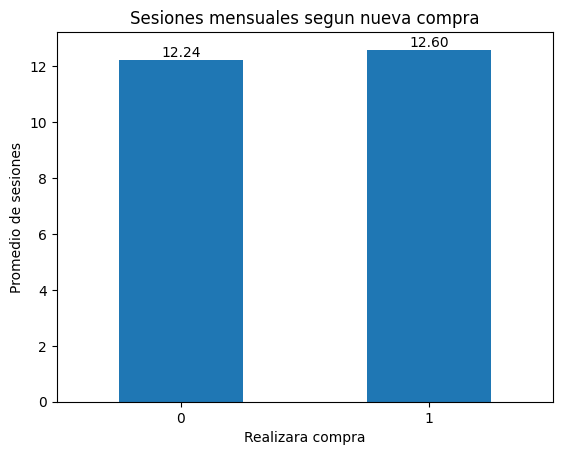

In [277]:
datos = df_prediccion.groupby("realizara_compra_30d")["sesiones_mes"].mean()

ax = datos.plot(kind="bar")

plt.xlabel("Realizara compra")
plt.ylabel("Promedio de sesiones")
plt.title("Sesiones mensuales segun nueva compra")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt="%.2f")

plt.show()

### Interpretacion

Los usuarios que no realizaran una compra tienen en promedio
12.24 sesiones por mes.

Los usuarios que si realizaran una compra tienen en promedio
12.60 sesiones.

La diferencia entre ambos grupos es pequeña.

Por lo tanto, la cantidad de sesiones por si sola no parece mostrar
una diferencia importante entre los usuarios que compran y los que no.

## 3.13 Patrones encontrados

Luego de revisar los datos se encontraron algunos patrones que pueden
ser utiles para realizar la prediccion.

Los usuarios que realizaran una nueva compra presentan en promedio:

- Una mayor cantidad de compras durante los ultimos 6 meses.
- Un gasto promedio mayor.
- Menos dias desde su ultima compra.

En cambio, variables como sesiones por mes y satisfaccion presentan
diferencias pequeñas entre los usuarios que compran y los que no.

Tambien se observo que ninguna variable por si sola tiene una relacion
muy fuerte con la compra.

Por esta razon, para realizar la prediccion sera necesario utilizar
varias caracteristicas de los usuarios al mismo tiempo.

## 3.14 Analisis del comportamiento de los usuarios

Ahora se revisara el archivo perfil_comportamiento.csv.

Este archivo contiene informacion sobre la forma en la que los usuarios
utilizan la plataforma, sus compras, gasto, descuentos, recomendaciones,
productos guardados y fidelidad.

El objetivo de este analisis es conocer mejor las diferencias que existen
entre los usuarios antes de intentar separarlos en grupos.

### Frecuencia de sesiones

Se revisara cuantas sesiones realizan normalmente los usuarios.

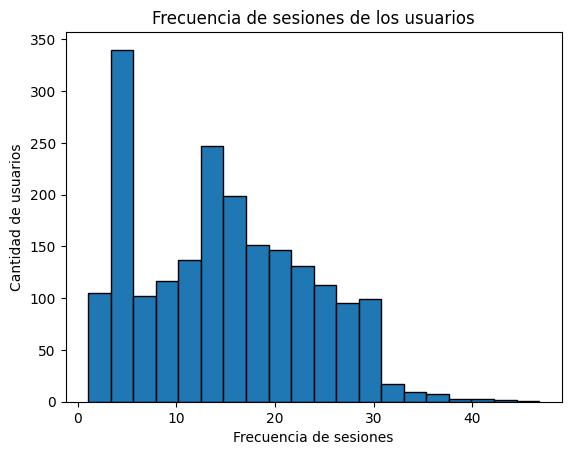

Promedio: 14.95
Mediana: 14.03
Minimo: 1.05
Maximo: 46.8


In [278]:
datos = df_perfil["frecuencia_sesiones"].dropna()

plt.hist(datos, bins=20, edgecolor="black")

plt.xlabel("Frecuencia de sesiones")
plt.ylabel("Cantidad de usuarios")
plt.title("Frecuencia de sesiones de los usuarios")

plt.show()

print("Promedio:", round(datos.mean(), 2))
print("Mediana:", round(datos.median(), 2))
print("Minimo:", round(datos.min(), 2))
print("Maximo:", round(datos.max(), 2))

### Compras mensuales

Ahora se revisara la cantidad de compras que realizan los usuarios
durante un mes.

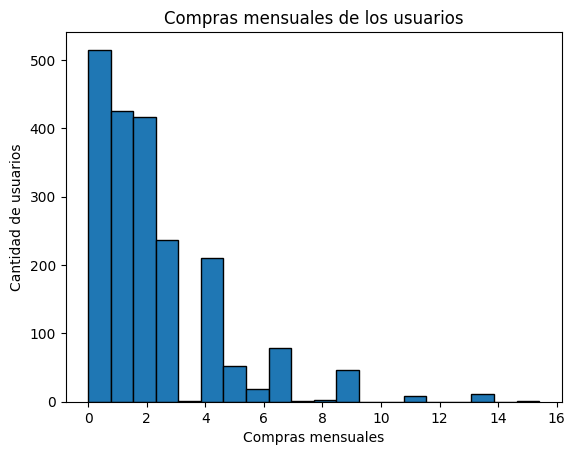

Promedio: 2.28
Mediana: 2.0
Minimo: 0.0
Maximo: 15.4


In [279]:
datos = df_perfil["compras_mensuales"].dropna()

plt.hist(datos, bins=20, edgecolor="black")

plt.xlabel("Compras mensuales")
plt.ylabel("Cantidad de usuarios")
plt.title("Compras mensuales de los usuarios")

plt.show()

print("Promedio:", round(datos.mean(), 2))
print("Mediana:", round(datos.median(), 2))
print("Minimo:", round(datos.min(), 2))
print("Maximo:", round(datos.max(), 2))

### Gasto mensual

Se revisara cuanto gastan los usuarios durante un mes.

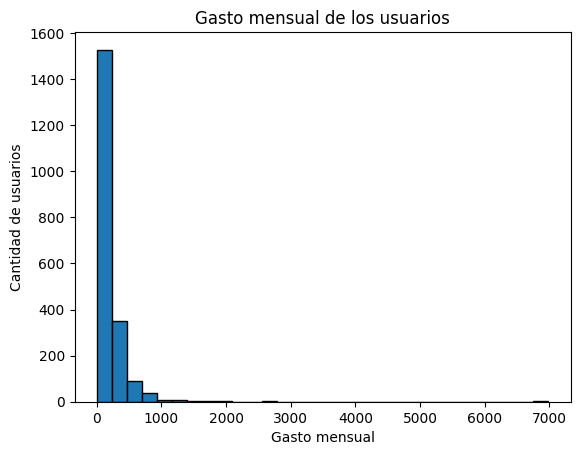

Promedio: 191.91
Mediana: 128.3
Minimo: 6.38
Maximo: 6977.94


In [280]:
datos = df_perfil["gasto_mensual"].dropna()

plt.hist(datos, bins=30, edgecolor="black")

plt.xlabel("Gasto mensual")
plt.ylabel("Cantidad de usuarios")
plt.title("Gasto mensual de los usuarios")

plt.show()

print("Promedio:", round(datos.mean(), 2))
print("Mediana:", round(datos.median(), 2))
print("Minimo:", round(datos.min(), 2))
print("Maximo:", round(datos.max(), 2))

### Fidelidad

Ahora se revisara el nivel de fidelidad de los usuarios.

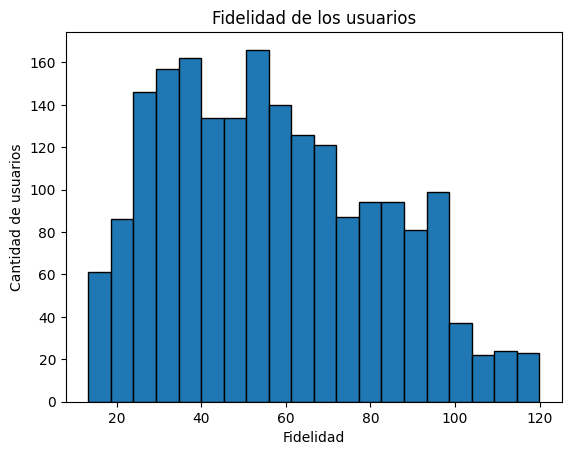

Promedio: 57.01
Mediana: 54.48
Minimo: 13.32
Maximo: 119.88


In [281]:
datos = df_perfil["fidelidad"].dropna()

plt.hist(datos, bins=20, edgecolor="black")

plt.xlabel("Fidelidad")
plt.ylabel("Cantidad de usuarios")
plt.title("Fidelidad de los usuarios")

plt.show()

print("Promedio:", round(datos.mean(), 2))
print("Mediana:", round(datos.median(), 2))
print("Minimo:", round(datos.min(), 2))
print("Maximo:", round(datos.max(), 2))

### Diversidad de categorias

Se revisara con cuantas categorias diferentes interactuan los usuarios.

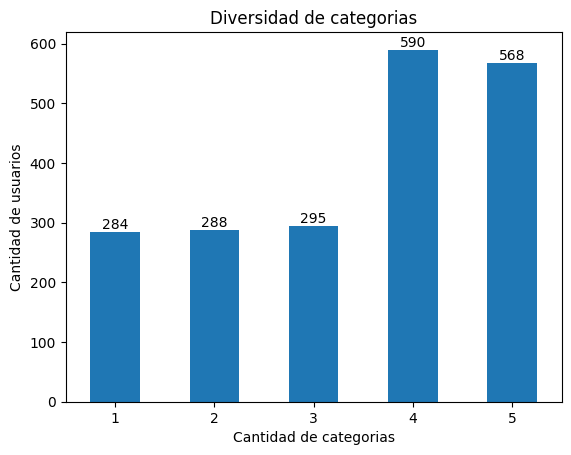

In [282]:
conteo = df_perfil["diversidad_categorias"].value_counts().sort_index()

ax = conteo.plot(kind="bar")

plt.xlabel("Cantidad de categorias")
plt.ylabel("Cantidad de usuarios")
plt.title("Diversidad de categorias")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0])

plt.show()

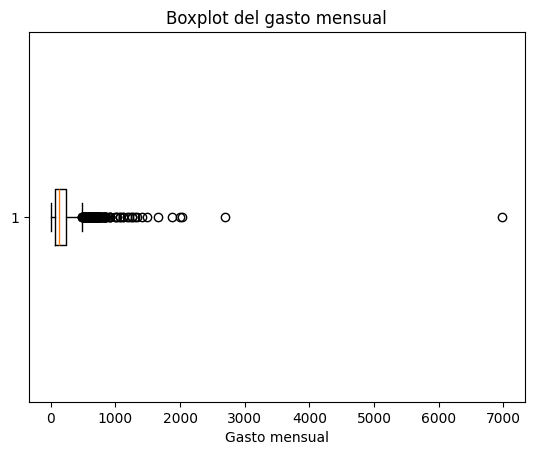

25%: 66.82
Mediana: 128.3
75%: 235.68
Maximo: 6977.94


In [283]:
datos = df_perfil["gasto_mensual"].dropna()

plt.boxplot(datos, vert=False)

plt.xlabel("Gasto mensual")
plt.title("Boxplot del gasto mensual")

plt.show()

print("25%:", round(datos.quantile(0.25), 2))
print("Mediana:", round(datos.median(), 2))
print("75%:", round(datos.quantile(0.75), 2))
print("Maximo:", round(datos.max(), 2))

### Interpretacion

La mediana del gasto mensual es de 128.30.

La mitad de los usuarios tiene un gasto aproximadamente entre 66.82
y 235.68.

Se observan varios valores alejados del resto, incluyendo un valor
maximo de 6977.94.

Estos valores deberan analizarse en la siguiente fase antes de decidir
si se mantienen o se modifican.

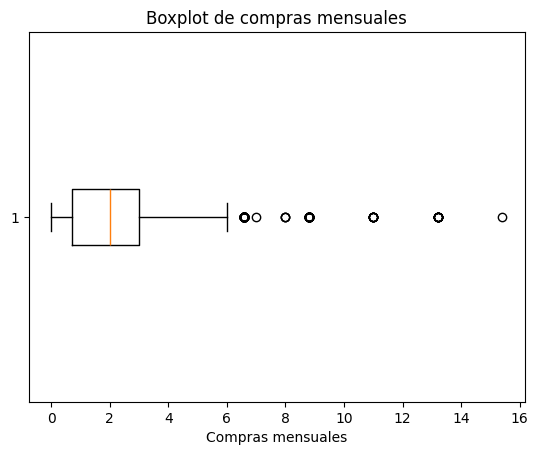

25%: 0.7
Mediana: 2.0
75%: 3.0
Maximo: 15.4


In [284]:
datos = df_perfil["compras_mensuales"].dropna()

plt.boxplot(datos, vert=False)

plt.xlabel("Compras mensuales")
plt.title("Boxplot de compras mensuales")

plt.show()

print("25%:", round(datos.quantile(0.25), 2))
print("Mediana:", round(datos.median(), 2))
print("75%:", round(datos.quantile(0.75), 2))
print("Maximo:", round(datos.max(), 2))

### Interpretacion

La mediana es de 2 compras mensuales.

La mitad de los usuarios realiza aproximadamente entre 0.70 y
3 compras por mes.

Tambien existen usuarios con una cantidad de compras bastante mayor,
llegando hasta 15.40.

Estos usuarios podrian representar clientes que compran con mucha
mayor frecuencia que el resto.

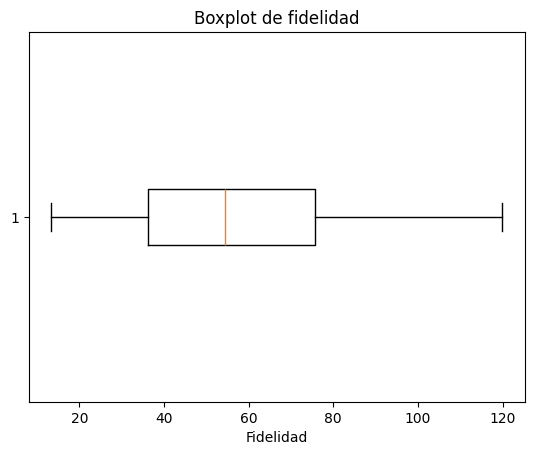

25%: 36.3
Mediana: 54.48
75%: 75.7
Maximo: 119.88


In [285]:
datos = df_perfil["fidelidad"].dropna()

plt.boxplot(datos, vert=False)

plt.xlabel("Fidelidad")
plt.title("Boxplot de fidelidad")

plt.show()

print("25%:", round(datos.quantile(0.25), 2))
print("Mediana:", round(datos.median(), 2))
print("75%:", round(datos.quantile(0.75), 2))
print("Maximo:", round(datos.max(), 2))

### Interpretacion

La mediana de fidelidad es de 54.48.

La mitad de los usuarios tiene valores aproximadamente entre 36.30
y 75.70.

Tambien se observan algunos valores altos alejados del resto,
incluyendo valores superiores a 100.

Estos valores se revisaran en la siguiente fase.

## 3.21 Relacion entre las variables de comportamiento

Ahora se revisara si existen relaciones entre las diferentes
caracteristicas de los usuarios.

Esto puede ayudar a entender que comportamientos suelen aparecer juntos.

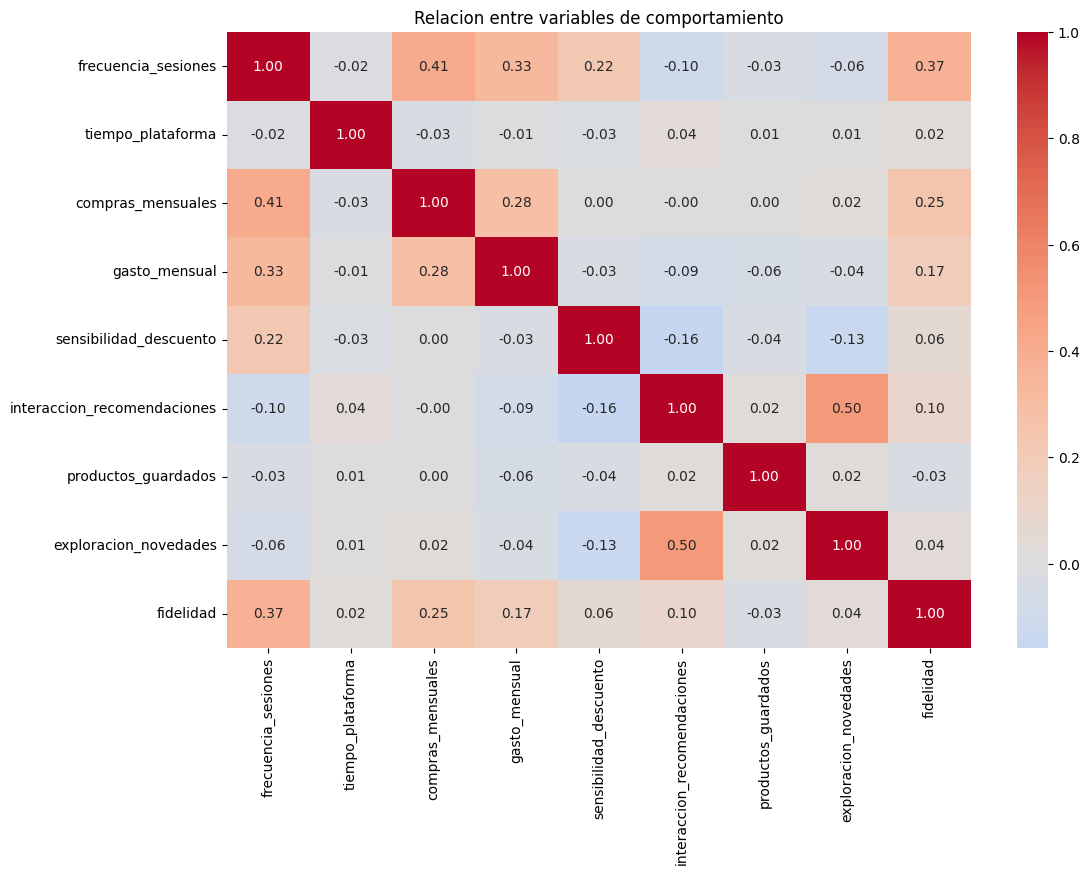

In [286]:
columnas_perfil = [
    "frecuencia_sesiones",
    "tiempo_plataforma",
    "compras_mensuales",
    "gasto_mensual",
    "sensibilidad_descuento",
    "interaccion_recomendaciones",
    "productos_guardados",
    "exploracion_novedades",
    "fidelidad"
]

corr_perfil = df_perfil[columnas_perfil].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_perfil,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Relacion entre variables de comportamiento")
plt.show()



Se encontraron algunas relaciones interesantes entre las variables.

La relacion mas alta se encuentra entre interaccion_recomendaciones
y exploracion_novedades, con aproximadamente 0.50.

Esto muestra que los usuarios que interactuan mas con las recomendaciones
tambien tienden a explorar mas productos nuevos.

La frecuencia de sesiones y las compras mensuales tienen una relacion
de aproximadamente 0.41.

Esto indica que los usuarios que ingresan mas a la plataforma tambien
tienden a realizar mas compras.

La frecuencia de sesiones y la fidelidad tienen una relacion cercana
a 0.38.

Tambien existe una relacion de aproximadamente 0.33 entre frecuencia
de sesiones y gasto mensual.

Estos resultados muestran que la actividad, las compras, el gasto
y la fidelidad pueden ayudar a diferenciar distintos tipos de usuarios.

## 3.22 Patrones encontrados

Luego de revisar el comportamiento de los usuarios se encontraron
varias diferencias que pueden ser utiles para encontrar grupos de clientes.

Se observo que:

- Existen usuarios con pocas sesiones y otros con una actividad mucho mayor.
- Algunos usuarios realizan pocas compras y otros compran con mucha frecuencia.
- Existen diferencias grandes en el gasto mensual.
- Los usuarios que tienen mas sesiones tienden a realizar mas compras.
- Los usuarios con mas sesiones tambien tienden a tener mayor fidelidad.
- Los usuarios que interactuan mas con recomendaciones tienden a explorar
  mas productos nuevos.
- Existen algunos valores muy alejados del resto que deberan revisarse
  antes de formar los grupos.

Estas diferencias indican que existen distintos comportamientos entre
los usuarios y que los datos pueden ser utiles para encontrar diferentes
tipos de clientes.

# FASE 4. Preparacion de los datos

En esta fase se prepararan los datos antes de utilizarlos para crear
los diferentes modelos.

Se revisaran y trataran las filas repetidas, los datos vacios y los
valores muy alejados del resto.

Tambien se prepararan las variables para que puedan ser utilizadas
correctamente en las siguientes fases.

## 4.1 Copia de los datos originales

Antes de comenzar la limpieza se crearan copias de los cuatro archivos.

De esta manera se podran realizar cambios sin modificar los datos
originales.

In [287]:
df_prediccion_limpio = df_prediccion.copy()
df_perfil_limpio = df_perfil.copy()
df_productos_limpio = df_productos.copy()
df_interacciones_limpio = df_interacciones.copy()

## 4.2 Tratamiento de filas repetidas

Durante la revision inicial se encontraron filas completamente repetidas.

Estas filas seran eliminadas porque representan la misma informacion
mas de una vez y podrian afectar los resultados.

In [288]:
print("Prediccion:", df_prediccion_limpio.duplicated().sum())
print("Perfil:", df_perfil_limpio.duplicated().sum())
print("Productos:", df_productos_limpio.duplicated().sum())
print("Interacciones:", df_interacciones_limpio.duplicated().sum())

Prediccion: 30
Perfil: 25
Productos: 10
Interacciones: 684


In [289]:
df_prediccion_limpio = df_prediccion_limpio.drop_duplicates()
df_perfil_limpio = df_perfil_limpio.drop_duplicates()
df_productos_limpio = df_productos_limpio.drop_duplicates()
df_interacciones_limpio = df_interacciones_limpio.drop_duplicates()

In [290]:
print("Prediccion:", df_prediccion_limpio.shape)
print("Perfil:", df_perfil_limpio.shape)
print("Productos:", df_productos_limpio.shape)
print("Interacciones:", df_interacciones_limpio.shape)

print("\nDuplicados restantes:")
print("Prediccion:", df_prediccion_limpio.duplicated().sum())
print("Perfil:", df_perfil_limpio.duplicated().sum())
print("Productos:", df_productos_limpio.duplicated().sum())
print("Interacciones:", df_interacciones_limpio.duplicated().sum())

Prediccion: (2000, 17)
Perfil: (2000, 13)
Productos: (500, 7)
Interacciones: (30053, 11)

Duplicados restantes:
Prediccion: 0
Perfil: 0
Productos: 0
Interacciones: 0


## 4.3 Revision de datos vacios

Despues de eliminar las filas repetidas se volveran a contar los
datos vacios.

Esto permitira decidir que hacer con ellos antes de continuar.

In [291]:
print("PREDICCION")
print(df_prediccion_limpio.isnull().sum())

print("\nPERFIL")
print(df_perfil_limpio.isnull().sum())

print("\nPRODUCTOS")
print(df_productos_limpio.isnull().sum())

print("\nINTERACCIONES")
print(df_interacciones_limpio.isnull().sum())

PREDICCION
id_usuario                        0
edad                              0
antiguedad_meses                  0
sesiones_mes                      0
minutos_promedio_sesion           0
productos_vistos                  0
productos_favoritos              30
compras_ultimos_6m                0
gasto_promedio                   40
descuento_utilizado               0
interacciones_recomendaciones     0
dias_desde_ultima_compra          0
satisfaccion                     50
canal_preferido                  30
categoria_favorita                0
dispositivo_principal             0
realizara_compra_30d              0
dtype: int64

PERFIL
id_usuario                      0
frecuencia_sesiones             0
tiempo_plataforma              40
diversidad_categorias           0
compras_mensuales               0
gasto_mensual                   0
sensibilidad_descuento         40
interaccion_recomendaciones     0
productos_guardados             0
resenas_realizadas              0
devoluciones    

## 4.4 Tratamiento de datos vacios del comportamiento

Los datos vacios del archivo de comportamiento se reemplazaran utilizando
la mediana de cada columna.

Se utilizara la mediana porque existen algunos valores muy alejados
del resto y de esta forma estos valores afectaran menos al resultado.

In [292]:
columnas_vacias_perfil = [
    "tiempo_plataforma",
    "sensibilidad_descuento",
    "fidelidad"
]

for columna in columnas_vacias_perfil:
    mediana = df_perfil_limpio[columna].median()
    df_perfil_limpio[columna] = df_perfil_limpio[columna].fillna(mediana)

In [293]:
df_perfil_limpio.isnull().sum()

,0
id_usuario,0
frecuencia_sesiones,0
tiempo_plataforma,0
diversidad_categorias,0
compras_mensuales,0
gasto_mensual,0
sensibilidad_descuento,0
interaccion_recomendaciones,0
productos_guardados,0
resenas_realizadas,0


Los datos vacios de tiempo_plataforma, sensibilidad_descuento y fidelidad
fueron reemplazados utilizando la mediana de cada variable.

No se eliminaron usuarios debido a estos datos vacios, ya que todavia
se podia conservar el resto de su informacion.

Despues de este proceso el archivo de comportamiento ya no contiene
datos vacios.

## 4.5 Tratamiento de datos vacios del catalogo

Los datos vacios de nivel de novedad y popularidad seran reemplazados
utilizando la mediana de cada variable.

De esta forma se pueden conservar los productos sin tener que eliminar
todo el registro.

In [294]:
df_productos_limpio["nivel_novedad"] = df_productos_limpio["nivel_novedad"].fillna(
    df_productos_limpio["nivel_novedad"].median()
)

df_productos_limpio["popularidad"] = df_productos_limpio["popularidad"].fillna(
    df_productos_limpio["popularidad"].median()
)
df_productos_limpio.isnull().sum()

,0
id_producto,0
categoria,0
subcategoria,0
precio,0
nivel_novedad,0
popularidad,0
sostenibilidad,0


## 4.6 Tratamiento de datos vacios de las interacciones

Algunas interacciones tienen informacion vacia sobre el producto.

Como cada interaccion contiene el identificador del producto, se utilizara
el catalogo para recuperar la categoria, precio, nivel de novedad y
popularidad cuando sea posible.

Para los datos de valoracion y tiempo de interaccion se utilizara
la mediana.

In [295]:
mapa_productos = df_productos_limpio.set_index("id_producto")

columnas_producto = [
    "categoria",
    "precio",
    "nivel_novedad",
    "popularidad"
]

for columna in columnas_producto:
    df_interacciones_limpio[columna] = df_interacciones_limpio[columna].fillna(
        df_interacciones_limpio["id_producto"].map(mapa_productos[columna])
    )


In [296]:
df_interacciones_limpio["valoracion"] = (
    df_interacciones_limpio["valoracion"].fillna(
        df_interacciones_limpio["valoracion"].median()
    )
)

df_interacciones_limpio["tiempo_interaccion_seg"] = (
    df_interacciones_limpio["tiempo_interaccion_seg"].fillna(
        df_interacciones_limpio["tiempo_interaccion_seg"].median()
    )
)

In [297]:
df_interacciones_limpio.isnull().sum()

,0
id_usuario,0
id_producto,0
categoria,0
subcategoria,0
precio,0
nivel_novedad,0
popularidad,0
tipo_interaccion,0
valoracion,0
tiempo_interaccion_seg,0


## 4.7 Datos vacios del archivo de prediccion

Los datos vacios del archivo de prediccion no seran reemplazados todavia.

Primero se separaran los datos que se utilizaran para aprender y los datos
que se utilizaran para comprobar el resultado.

Luego los valores vacios seran tratados dentro del proceso de preparacion
del modelo.

Esto permite evitar mezclar informacion entre ambos grupos.

## 4.8 Tratamiento de valores muy alejados

Durante el analisis anterior se encontraron algunos valores muy alejados
del resto.

Estos valores pueden afectar la formacion de los grupos, ya que algunos
usuarios podrian tener valores mucho mayores que los demas.

En lugar de eliminar usuarios completos, se limitaran solamente los valores
que se encuentren demasiado alejados.

Para encontrar estos limites se utilizaran el 25% y 75% de los datos.

In [298]:
columnas_revisar = [
    "frecuencia_sesiones",
    "tiempo_plataforma",
    "compras_mensuales",
    "gasto_mensual",
    "interaccion_recomendaciones",
    "productos_guardados",
    "resenas_realizadas",
    "devoluciones"
]

for columna in columnas_revisar:

    q1 = df_perfil_limpio[columna].quantile(0.25)
    q3 = df_perfil_limpio[columna].quantile(0.75)

    rango = q3 - q1

    limite_inferior = q1 - 1.5 * rango
    limite_superior = q3 + 1.5 * rango

    cantidad = (
        (df_perfil_limpio[columna] < limite_inferior) |
        (df_perfil_limpio[columna] > limite_superior)
    ).sum()

    print(columna, ":", cantidad)

frecuencia_sesiones : 1
tiempo_plataforma : 52
compras_mensuales : 150
gasto_mensual : 131
interaccion_recomendaciones : 161
productos_guardados : 2
resenas_realizadas : 12
devoluciones : 59


In [299]:
for columna in columnas_revisar:

    q1 = df_perfil_limpio[columna].quantile(0.25)
    q3 = df_perfil_limpio[columna].quantile(0.75)

    rango = q3 - q1

    limite_inferior = q1 - 1.5 * rango
    limite_superior = q3 + 1.5 * rango

    df_perfil_limpio[columna] = df_perfil_limpio[columna].clip(
        limite_inferior,
        limite_superior
    )

## 4.9 Preparacion de los datos de prediccion

Para crear el modelo se separaran las caracteristicas de los usuarios
de la variable que se quiere predecir.

La columna id_usuario no se utilizara para realizar la prediccion,
ya que solamente sirve para identificar a cada usuario.

La variable que se quiere predecir es realizara_compra_30d.

In [300]:
X = df_prediccion_limpio.drop(
    columns=["id_usuario", "realizara_compra_30d"]
)

y = df_prediccion_limpio["realizara_compra_30d"]

In [301]:
print("Datos de entrada:", X.shape)
print("Resultado:", y.shape)

Datos de entrada: (2000, 15)
Resultado: (2000,)


## 4.10 Separacion de los datos

Los datos se dividiran en dos partes.

- 80% se utilizara para que el modelo aprenda.
- 20% se utilizara para comprobar que tan bien funciona.

La separacion mantendra aproximadamente la misma cantidad proporcional
de usuarios que compran y que no compran en ambos grupos.

In [302]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [303]:
print("Datos para aprender:", X_train.shape)
print("Datos para comprobar:", X_test.shape)

print("\nCompra en datos para aprender:")
print(y_train.value_counts())

print("\nCompra en datos para comprobar:")
print(y_test.value_counts())

Datos para aprender: (1600, 15)
Datos para comprobar: (400, 15)

Compra en datos para aprender:
realizara_compra_30d
0    1177
1     423
Name: count, dtype: int64

Compra en datos para comprobar:
realizara_compra_30d
0    294
1    106
Name: count, dtype: int64


## 4.11 Valores alejados en los datos de prediccion

Tambien se encontraron algunos valores alejados en el archivo de prediccion.

Los limites se calcularan utilizando solamente los datos destinados
al aprendizaje.

Despues se utilizaran los mismos limites en los datos destinados
a comprobar el modelo.

In [304]:
columnas_limitar = [
    "antiguedad_meses",
    "sesiones_mes",
    "minutos_promedio_sesion",
    "productos_vistos",
    "productos_favoritos",
    "compras_ultimos_6m",
    "gasto_promedio",
    "descuento_utilizado",
    "interacciones_recomendaciones",
    "dias_desde_ultima_compra"
]

limites_prediccion = {}

for columna in columnas_limitar:

    q1 = X_train[columna].quantile(0.25)
    q3 = X_train[columna].quantile(0.75)

    rango = q3 - q1

    limite_inferior = q1 - 1.5 * rango
    limite_superior = q3 + 1.5 * rango

    limites_prediccion[columna] = (
        limite_inferior,
        limite_superior
    )

    X_train[columna] = X_train[columna].clip(
        limite_inferior,
        limite_superior
    )

    X_test[columna] = X_test[columna].clip(
        limite_inferior,
        limite_superior
    )

## 4.12 Variables numericas y de categoria

Las variables numericas y las variables de categoria se prepararan
de diferente manera.

Los datos numericos seran completados cuando exista algun valor vacio
y posteriormente seran puestos en una escala similar.

Las variables de categoria tambien seran completadas cuando exista
un dato vacio y luego seran convertidas en valores que el modelo pueda usar.

In [305]:
columnas_numericas = X_train.select_dtypes(include="number").columns

columnas_categoria = X_train.select_dtypes(exclude="number").columns

print("Numericas:")
print(columnas_numericas)

print("\nCategorias:")
print(columnas_categoria)

Numericas:
Index(['edad', 'antiguedad_meses', 'sesiones_mes', 'minutos_promedio_sesion',
       'productos_vistos', 'productos_favoritos', 'compras_ultimos_6m',
       'gasto_promedio', 'descuento_utilizado',
       'interacciones_recomendaciones', 'dias_desde_ultima_compra',
       'satisfaccion'],
      dtype='object')

Categorias:
Index(['canal_preferido', 'categoria_favorita', 'dispositivo_principal'], dtype='object')


In [306]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [307]:
preparacion_numerica = Pipeline([
    ("vacios", SimpleImputer(strategy="median")),
    ("escala", StandardScaler())
])

In [308]:
preparacion_categoria = Pipeline([
    ("vacios", SimpleImputer(strategy="most_frequent")),
    ("convertir", OneHotEncoder(handle_unknown="ignore"))
])

In [309]:
preparacion = ColumnTransformer([
    ("numericas", preparacion_numerica, columnas_numericas),
    ("categorias", preparacion_categoria, columnas_categoria)
])

## 4.14 Preparacion de los datos para formar grupos

Para encontrar los diferentes tipos de clientes se utilizaran las
variables del archivo de comportamiento.

La columna id_usuario no sera utilizada para formar los grupos,
ya que solamente identifica a cada usuario.

Las variables seran puestas en una escala similar para que ninguna
tenga mas importancia solamente por utilizar numeros mayores.

In [310]:
X_grupos = df_perfil_limpio.drop(columns=["id_usuario"])

In [311]:
from sklearn.preprocessing import StandardScaler

escalador_grupos = StandardScaler()

X_grupos_escalado = escalador_grupos.fit_transform(X_grupos)

In [312]:
print(X_grupos.shape)
print(X_grupos_escalado.shape)

(2000, 12)
(2000, 12)


In [313]:
print("Duplicados:")

print("Prediccion:", df_prediccion_limpio.duplicated().sum())
print("Perfil:", df_perfil_limpio.duplicated().sum())
print("Productos:", df_productos_limpio.duplicated().sum())
print("Interacciones:", df_interacciones_limpio.duplicated().sum())

print("\nNulos perfil:")
print(df_perfil_limpio.isnull().sum().sum())

print("\nNulos productos:")
print(df_productos_limpio.isnull().sum().sum())

print("\nNulos interacciones:")
print(df_interacciones_limpio.isnull().sum().sum())

Duplicados:
Prediccion: 0
Perfil: 0
Productos: 0
Interacciones: 27

Nulos perfil:
0

Nulos productos:
0

Nulos interacciones:
0


In [314]:
print("Duplicados antes:", df_interacciones_limpio.duplicated().sum())

df_interacciones_limpio = df_interacciones_limpio.drop_duplicates()

print("Duplicados despues:", df_interacciones_limpio.duplicated().sum())
print("Cantidad de filas:", df_interacciones_limpio.shape[0])

Duplicados antes: 27
Duplicados despues: 0
Cantidad de filas: 30026


In [315]:
print("Duplicados:")

print("Duplicados prediccion:", df_prediccion_limpio.duplicated().sum())
print("Duplicados perfil:", df_perfil_limpio.duplicated().sum())
print("Duplicados productos:", df_productos_limpio.duplicated().sum())
print("Duplicados interacciones:", df_interacciones_limpio.duplicated().sum())

print("Nulos perfil:", df_perfil_limpio.isnull().sum().sum())
print("Nulos productos:", df_productos_limpio.isnull().sum().sum())
print("Nulos interacciones:", df_interacciones_limpio.isnull().sum().sum())

Duplicados:
Duplicados prediccion: 0
Duplicados perfil: 0
Duplicados productos: 0
Duplicados interacciones: 0
Nulos perfil: 0
Nulos productos: 0
Nulos interacciones: 0


In [316]:
print("Prediccion:", df_prediccion_limpio.shape)
print("Perfil:", df_perfil_limpio.shape)
print("Productos:", df_productos_limpio.shape)
print("Interacciones:", df_interacciones_limpio.shape)

Prediccion: (2000, 17)
Perfil: (2000, 13)
Productos: (500, 7)
Interacciones: (30026, 11)


## 4.16 Conclusion

Los datos fueron preparados antes de comenzar con los modelos.

Se eliminaron las filas completamente repetidas y se trataron los datos
vacios.

Tambien se revisaron y limitaron algunos valores muy alejados del resto.

Para la prediccion, los datos fueron separados en un 80% para aprendizaje
y un 20% para comprobar los resultados.

Las variables numericas seran completadas utilizando la mediana y
posteriormente puestas en una escala similar.

Las variables de categoria seran completadas utilizando la opcion mas
frecuente y convertidas a valores que puedan utilizar los modelos.

Finalmente, los datos de comportamiento tambien fueron preparados
para posteriormente encontrar diferentes grupos de clientes.

# FASE 5. Aprendizaje supervisado

En esta fase se crearan modelos para predecir si un usuario realizara
una compra durante los proximos 30 dias.

Primero se utilizara Regresion Logistica.

Despues se comparara con otros modelos para ver cual obtiene mejores resultados.

## 5.1 Regresion Logistica

El primer modelo utilizado sera Regresion Logistica.

Este modelo intentara predecir:

- 0 = El usuario no realizara una compra.
- 1 = El usuario si realizara una compra.

In [317]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

modelo_logistico = Pipeline([
    ("preparacion", preparacion),
    ("modelo", LogisticRegression(max_iter=1000, random_state=42))
])

modelo_logistico.fit(X_train, y_train)

Pipeline(steps=[('preparacion',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('vacios',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escala',
                                                                   StandardScaler())]),
                                                  Index(['edad', 'antiguedad_meses', 'sesiones_mes', 'minutos_promedio_sesion',
       'productos_vistos', 'productos_favoritos', 'compras_ultimos_6m',
       'gasto_promedio', 'descuento_utilizado',
       'interacc..., 'dias_desde_ultima_compra',
       'satisfaccion'],
      dtype='object')),
                                                 ('categorias',
                                                  Pipeline(steps=[('vacios',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('convertir',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['canal_preferido', 'categoria_favorita', 'dispositivo_principal'], dtype='object'))])),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

## 5.2 Predicciones

Ahora se utilizara el modelo con los datos que fueron separados
para comprobar sus resultados.

In [318]:
y_pred_logistico = modelo_logistico.predict(X_test)

print("Primeras predicciones:")
print(y_pred_logistico[:20])

Primeras predicciones:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 5.3 Resultados de Regresion Logistica

Se evaluara que tan bien funciona el modelo utilizando diferentes medidas.

In [319]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred_logistico)
precision = precision_score(y_test, y_pred_logistico)
recall = recall_score(y_test, y_pred_logistico)
f1 = f1_score(y_test, y_pred_logistico)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1:", round(f1, 4))

Accuracy: 0.7325
Precision: 0.4
Recall: 0.0189
F1: 0.036


## 5.4 Matriz de confusion

Ahora se revisara en cuantos casos el modelo acerto y en cuantos
casos se equivoco.

[[291   3]
 [104   2]]


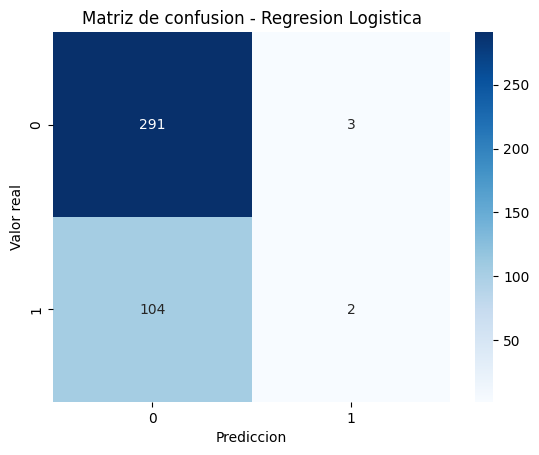

In [320]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

matriz = confusion_matrix(y_test, y_pred_logistico)

print(matriz)

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.title("Matriz de confusion - Regresion Logistica")

plt.show()

El modelo obtuvo un Accuracy de 0.7325, por lo que acerto aproximadamente
el 73.25% de los casos.

Sin embargo, el resultado no es tan bueno como parece.

De los 106 usuarios que realmente realizaran una compra, el modelo solamente
identifico correctamente a 2.

El Recall fue de 0.0189, lo que muestra que el modelo tiene muchos problemas
para encontrar a los usuarios que si realizaran una compra.

Esto ocurre porque existen muchos mas usuarios con valor 0 que usuarios
con valor 1.

Por esta razon, este primer modelo todavia no seria suficientemente bueno
para utilizarlo en una decision real.

## 5.6 Arbol de Decision

Ahora se utilizara un Arbol de Decision para intentar predecir si un
usuario realizara una compra durante los proximos 30 dias.

Se limitara la profundidad del arbol para evitar que aprenda demasiado
los datos de entrenamiento.

In [321]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = Pipeline([
    ("preparacion", preparacion),
    ("modelo", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

modelo_arbol.fit(X_train, y_train)

Pipeline(steps=[('preparacion',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('vacios',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escala',
                                                                   StandardScaler())]),
                                                  Index(['edad', 'antiguedad_meses', 'sesiones_mes', 'minutos_promedio_sesion',
       'productos_vistos', 'productos_favoritos', 'compras_ultimos_6m',
       'gasto_promedio', 'descuento_utilizado',
       'interacc...dias_desde_ultima_compra',
       'satisfaccion'],
      dtype='object')),
                                                 ('categorias',
                                                  Pipeline(steps=[('vacios',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('convertir',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['canal_preferido', 'categoria_favorita', 'dispositivo_principal'], dtype='object'))])),
                ('modelo',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

## 5.7 Predicciones del Arbol de Decision

Ahora se utilizaran los datos de prueba para comprobar los resultados
del Arbol de Decision.

In [322]:
y_pred_arbol = modelo_arbol.predict(X_test)

print("Primeras predicciones:")
print(y_pred_arbol[:20])

Primeras predicciones:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]


## 5.8 Resultados del Arbol de Decision

Se calcularan los mismos valores utilizados anteriormente para poder
comparar este modelo con Regresion Logistica.

In [323]:
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
precision_arbol = precision_score(y_test, y_pred_arbol)
recall_arbol = recall_score(y_test, y_pred_arbol)
f1_arbol = f1_score(y_test, y_pred_arbol)

print("Accuracy:", round(accuracy_arbol, 4))
print("Precision:", round(precision_arbol, 4))
print("Recall:", round(recall_arbol, 4))
print("F1:", round(f1_arbol, 4))

Accuracy: 0.7125
Precision: 0.2353
Recall: 0.0377
F1: 0.065


[[281  13]
 [102   4]]


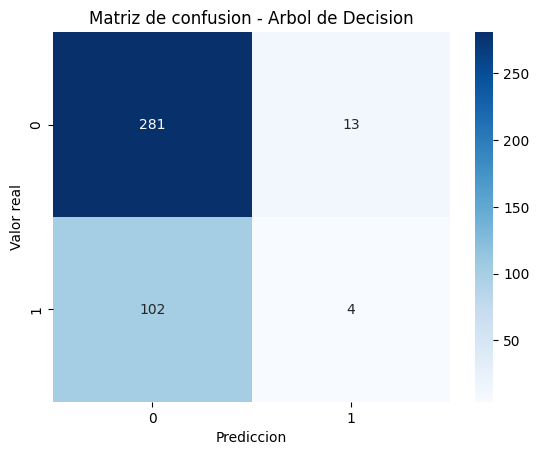

In [324]:
matriz_arbol = confusion_matrix(y_test, y_pred_arbol)

print(matriz_arbol)

sns.heatmap(
    matriz_arbol,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.title("Matriz de confusion - Arbol de Decision")

plt.show()

El Arbol de Decision obtuvo un Accuracy de 0.7125.

De los 106 usuarios que realmente realizaran una compra, el modelo
identifico correctamente a 4.

El Recall fue de 0.0377, por lo que sigue teniendo dificultades para
encontrar a los usuarios que si realizaran una compra.

Comparado con Regresion Logistica, el Arbol encontro mas usuarios que
si compraran, aunque tambien cometio mas errores.

Por el momento ninguno de los dos modelos tiene resultados suficientes
para utilizarse en una decision real.

## 5.11 Random Forest

Ahora se utilizara Random Forest para realizar la misma prediccion.

Este modelo utiliza varios arboles de decision y combina sus resultados
para obtener una prediccion final.

In [325]:
from sklearn.ensemble import RandomForestClassifier

modelo_random_forest = Pipeline([
    ("preparacion", preparacion),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

modelo_random_forest.fit(X_train, y_train)

Pipeline(steps=[('preparacion',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('vacios',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escala',
                                                                   StandardScaler())]),
                                                  Index(['edad', 'antiguedad_meses', 'sesiones_mes', 'minutos_promedio_sesion',
       'productos_vistos', 'productos_favoritos', 'compras_ultimos_6m',
       'gasto_promedio', 'descuento_utilizado',
       'interacc...ndaciones', 'dias_desde_ultima_compra',
       'satisfaccion'],
      dtype='object')),
                                                 ('categorias',
                                                  Pipeline(steps=[('vacios',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('convertir',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['canal_preferido', 'categoria_favorita', 'dispositivo_principal'], dtype='object'))])),
                ('modelo', RandomForestClassifier(random_state=42))])

## 5.12 Predicciones de Random Forest

Ahora se utilizara Random Forest con los datos de prueba para comprobar
sus resultados.

In [326]:
y_pred_random = modelo_random_forest.predict(X_test)

print("Primeras predicciones:")
print(y_pred_random[:20])

Primeras predicciones:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 5.13 Resultados de Random Forest

Se calcularan Accuracy, Precision, Recall y F1 para comparar Random Forest
con los modelos anteriores.

In [327]:
accuracy_random = accuracy_score(y_test, y_pred_random)
precision_random = precision_score(y_test, y_pred_random)
recall_random = recall_score(y_test, y_pred_random)
f1_random = f1_score(y_test, y_pred_random)

print("Accuracy:", round(accuracy_random, 4))
print("Precision:", round(precision_random, 4))
print("Recall:", round(recall_random, 4))
print("F1:", round(f1_random, 4))

Accuracy: 0.73
Precision: 0.375
Recall: 0.0283
F1: 0.0526


[[289   5]
 [103   3]]


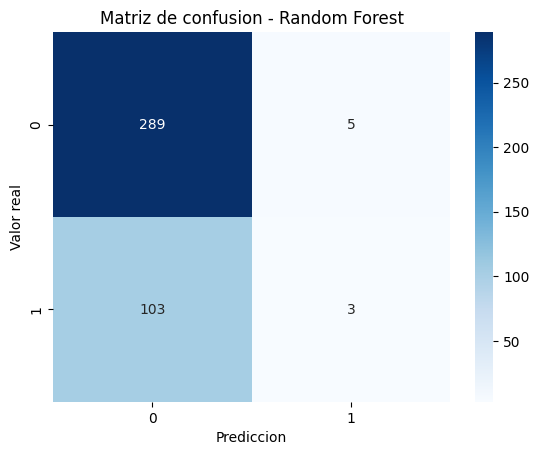

In [328]:
matriz_random = confusion_matrix(y_test, y_pred_random)

print(matriz_random)

sns.heatmap(
    matriz_random,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.title("Matriz de confusion - Random Forest")

plt.show()

## 5.15 Interpretacion de Random Forest

Random Forest obtuvo un Accuracy de 0.73.

De los 106 usuarios que realmente realizaran una compra, solamente
identifico correctamente a 3.

El Recall fue de 0.0283, por lo que sigue teniendo dificultades para
identificar a los usuarios que si realizaran una compra.

Aunque el Accuracy parece alto, el modelo predice principalmente a los
usuarios que no compraran.

Por esta razon, Random Forest tampoco seria suficientemente bueno
para utilizarlo directamente en una decision real.

## 5.16 Comparacion de modelos

Finalmente se compararan los resultados de Regresion Logistica,
Arbol de Decision y Random Forest.

In [329]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresion Logistica",
        "Arbol de Decision",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_arbol,
        accuracy_random
    ],
    "Precision": [
        precision,
        precision_arbol,
        precision_random
    ],
    "Recall": [
        recall,
        recall_arbol,
        recall_random
    ],
    "F1": [
        f1,
        f1_arbol,
        f1_random
    ]
})

comparacion_modelos.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Regresion Logistica,0.7325,0.4000,0.0189,0.0360
1,Arbol de Decision,0.7125,0.2353,0.0377,0.0650
2,Random Forest,0.7300,0.3750,0.0283,0.0526


Los tres modelos tienen un Accuracy cercano al 70%, pero tienen problemas
para identificar correctamente a los usuarios que si realizaran una compra.

El Arbol de Decision obtuvo el Recall mas alto de los tres modelos,
aunque sigue siendo bastante bajo.

Regresion Logistica obtuvo el Accuracy ligeramente mas alto.

Los resultados muestran que ninguno de los tres modelos es suficientemente
confiable para apoyar una decision real en su estado actual.

Una posible causa es que existen muchos mas usuarios que no compran
que usuarios que si compran.

## 5.17 Mejora por diferencia entre grupos

En los datos existen muchos mas usuarios que no realizaran una compra
que usuarios que si realizaran una compra.

Por esta razon se intentara dar mayor importancia al grupo con menos
usuarios para comprobar si el modelo puede identificar mejor a los
clientes que si compraran.

In [330]:
modelo_logistico_balanceado = Pipeline([
    ("preparacion", preparacion),
    ("modelo", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

modelo_logistico_balanceado.fit(X_train, y_train)

y_pred_logistico_balanceado = modelo_logistico_balanceado.predict(X_test)

In [331]:
accuracy_log_bal = accuracy_score(y_test, y_pred_logistico_balanceado)
precision_log_bal = precision_score(y_test, y_pred_logistico_balanceado)
recall_log_bal = recall_score(y_test, y_pred_logistico_balanceado)
f1_log_bal = f1_score(y_test, y_pred_logistico_balanceado)

print("Accuracy:", round(accuracy_log_bal, 4))
print("Precision:", round(precision_log_bal, 4))
print("Recall:", round(recall_log_bal, 4))
print("F1:", round(f1_log_bal, 4))

Accuracy: 0.59
Precision: 0.3232
Recall: 0.5
F1: 0.3926


[[183 111]
 [ 53  53]]


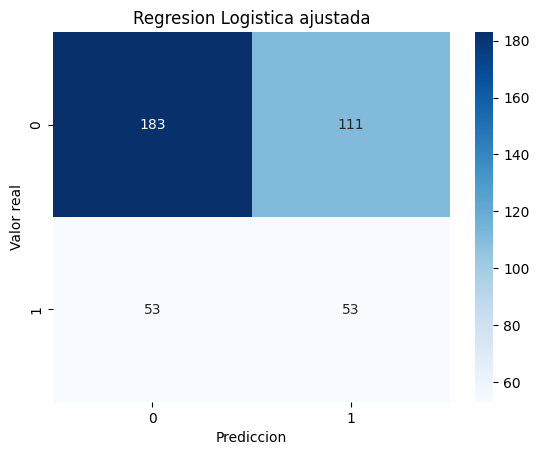

In [332]:
matriz_log_bal = confusion_matrix(
    y_test,
    y_pred_logistico_balanceado
)

print(matriz_log_bal)

sns.heatmap(
    matriz_log_bal,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.title("Regresion Logistica ajustada")

plt.show()

Al ajustar la diferencia entre los grupos, el modelo identifico correctamente
a 53 de los 106 usuarios que realmente realizaran una compra.

El Recall aumento de 0.0189 a 0.50.

El Accuracy disminuyo de 0.7325 a 0.59, pero ahora el modelo es mucho mejor
para encontrar a los usuarios que si realizaran una compra.

Esto muestra que utilizar solamente Accuracy podia dar una idea equivocada
sobre el funcionamiento del modelo.

In [333]:
modelo_arbol_balanceado = Pipeline([
    ("preparacion", preparacion),
    ("modelo", DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
        class_weight="balanced"
    ))
])

modelo_arbol_balanceado.fit(X_train, y_train)

y_pred_arbol_balanceado = modelo_arbol_balanceado.predict(X_test)

In [334]:
print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred_arbol_balanceado), 4)
)

print(
    "Precision:",
    round(precision_score(y_test, y_pred_arbol_balanceado), 4)
)

print(
    "Recall:",
    round(recall_score(y_test, y_pred_arbol_balanceado), 4)
)

print(
    "F1:",
    round(f1_score(y_test, y_pred_arbol_balanceado), 4)
)

Accuracy: 0.6425
Precision: 0.3445
Recall: 0.3868
F1: 0.3644


In [335]:
comparacion_final = pd.DataFrame({
    "Modelo": [
        "Logistica original",
        "Logistica ajustada",
        "Arbol original",
        "Arbol ajustado",
        "Random Forest original"
    ],
    "Accuracy": [
        accuracy,
        accuracy_log_bal,
        accuracy_arbol,
        accuracy_score(y_test, y_pred_arbol_balanceado),
        accuracy_random
    ],
    "Precision": [
        precision,
        precision_log_bal,
        precision_arbol,
        precision_score(y_test, y_pred_arbol_balanceado),
        precision_random
    ],
    "Recall": [
        recall,
        recall_log_bal,
        recall_arbol,
        recall_score(y_test, y_pred_arbol_balanceado),
        recall_random
    ],
    "F1": [
        f1,
        f1_log_bal,
        f1_arbol,
        f1_score(y_test, y_pred_arbol_balanceado),
        f1_random
    ]
})

comparacion_final.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Logistica original,0.7325,0.4000,0.0189,0.0360
1,Logistica ajustada,0.5900,0.3232,0.5000,0.3926
2,Arbol original,0.7125,0.2353,0.0377,0.0650
3,Arbol ajustado,0.6425,0.3445,0.3868,0.3644
4,Random Forest original,0.7300,0.3750,0.0283,0.0526


## 5.22 Conclusion de los modelos

El modelo que mejor identifica a los usuarios que si realizaran una compra
es la Regresion Logistica ajustada.

Su Recall fue de 0.50, lo que significa que identifico correctamente
a la mitad de los compradores.

Aunque su Accuracy es menor, su resultado es mas util para el objetivo
del proyecto porque logra encontrar una mayor cantidad de clientes
que podrian realizar una compra.

Aun asi, el modelo todavia puede mejorar y no deberia utilizarse como
la unica informacion para tomar una decision real.

## 5.23 Variables mas importantes

Ahora se revisara que variables tuvieron mayor importancia para realizar
la prediccion.

Se utilizara el modelo de Regresion Logistica ajustada, ya que fue el que
mejor logro identificar a los usuarios que si realizaran una compra.

In [336]:
nombres_variables = (
    modelo_logistico_balanceado
    .named_steps["preparacion"]
    .get_feature_names_out()
)

valores = (
    modelo_logistico_balanceado
    .named_steps["modelo"]
    .coef_[0]
)

importancia_variables = pd.DataFrame({
    "Variable": nombres_variables,
    "Valor": valores
})

importancia_variables["Importancia"] = (
    importancia_variables["Valor"].abs()
)

importancia_variables = importancia_variables.sort_values(
    "Importancia",
    ascending=False
)

importancia_variables.head(10)

,Variable,Valor,Importancia
6,numericas__compras_ultimos_6m,0.273073,0.273073
10,numericas__dias_desde_ultima_compra,-0.241587,0.241587
7,numericas__gasto_promedio,0.198332,0.198332
2,numericas__sesiones_mes,0.109185,0.109185
8,numericas__descuento_utilizado,0.091004,0.091004
1,numericas__antiguedad_meses,0.090370,0.090370
9,numericas__interacciones_recomendaciones,0.080726,0.080726
4,numericas__productos_vistos,0.077017,0.077017
15,categorias__categoria_favorita_Bienestar,0.075215,0.075215
13,categorias__canal_preferido_Tablet,0.070054,0.070054


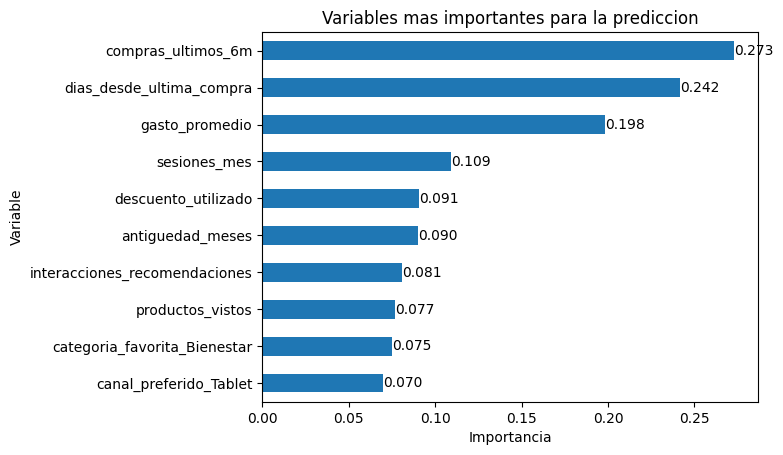

In [337]:
top_variables = importancia_variables.head(10).copy()

top_variables["Variable"] = (
    top_variables["Variable"]
    .str.replace("numericas__", "", regex=False)
    .str.replace("categorias__", "", regex=False)
)

top_variables = top_variables.sort_values("Importancia")

ax = top_variables.plot(
    x="Variable",
    y="Importancia",
    kind="barh",
    legend=False
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Variables mas importantes para la prediccion")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

## 5.25 Interpretacion de las variables importantes

Las variables que mas ayudaron al modelo fueron:

1. compras_ultimos_6m.
2. dias_desde_ultima_compra.
3. gasto_promedio.

La cantidad de compras anteriores fue la variable con mayor importancia.

Los dias desde la ultima compra tambien fueron importantes, pero su valor
es negativo. Esto indica que mientras mas tiempo pasa desde la ultima compra,
disminuye la posibilidad de que el usuario vuelva a comprar.

El gasto promedio tambien tiene importancia, mostrando que los usuarios
que gastan mas tienen una mayor tendencia a realizar una nueva compra.

Estos resultados coinciden con lo observado anteriormente durante
el analisis de los datos.

# FASE 6. Grupos de clientes

En esta fase se buscaran grupos de usuarios que tengan comportamientos
parecidos.

Para esto se utilizara K-Means con los datos del archivo
perfil_comportamiento.csv.

## 6.1 Cantidad de grupos

Antes de formar los grupos se probaran diferentes cantidades.

Se compararan valores entre 2 y 8 grupos para encontrar una cantidad
adecuada para los datos.

In [338]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados_grupos = []

for k in range(2, 9):

    modelo_k = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    grupos_k = modelo_k.fit_predict(X_grupos_escalado)

    resultados_grupos.append({
        "Grupos": k,
        "Inercia": modelo_k.inertia_,
        "Silhouette": silhouette_score(X_grupos_escalado, grupos_k)
    })

resultados_grupos = pd.DataFrame(resultados_grupos)

resultados_grupos.round(4)

,Grupos,Inercia,Silhouette
0,2,20684.2067,0.1388
1,3,18163.6842,0.1460
2,4,16977.7080,0.1394
3,5,16494.0429,0.1119
4,6,16078.7191,0.1004
5,7,15632.6257,0.0910
6,8,15248.7150,0.0866


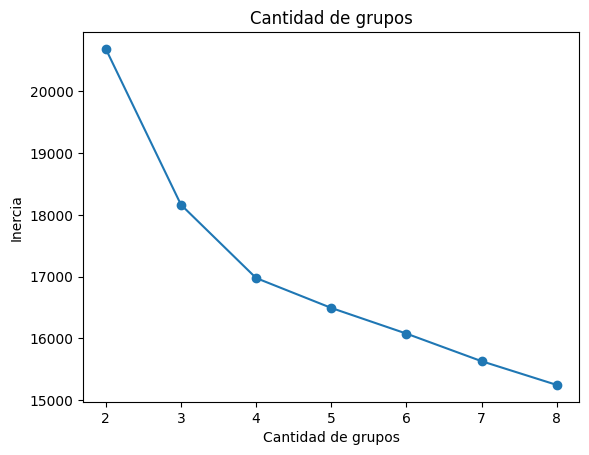

In [339]:
plt.plot(
    resultados_grupos["Grupos"],
    resultados_grupos["Inercia"],
    marker="o"
)

plt.xlabel("Cantidad de grupos")
plt.ylabel("Inercia")
plt.title("Cantidad de grupos")

plt.show()

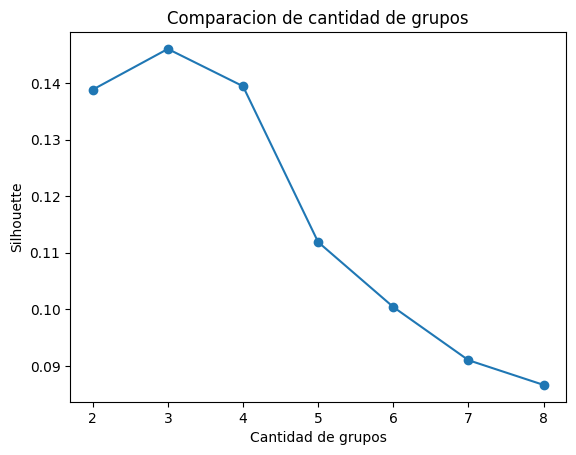

In [340]:
plt.plot(
    resultados_grupos["Grupos"],
    resultados_grupos["Silhouette"],
    marker="o"
)

plt.xlabel("Cantidad de grupos")
plt.ylabel("Silhouette")
plt.title("Comparacion de cantidad de grupos")

plt.show()

### Interpretacion

El valor mas alto de Silhouette se obtiene utilizando 3 grupos,
con un resultado aproximado de 0.1460.

Tambien se observa que despues de 3 grupos la mejora comienza a ser menor.

Por esta razon se utilizaran 3 grupos para separar a los usuarios.

## 6.3 Creacion de los grupos

Luego de comparar diferentes cantidades se utilizaran 3 grupos.

Cada usuario sera colocado en el grupo que tenga un comportamiento
mas parecido al suyo.

In [341]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

grupos = kmeans.fit_predict(X_grupos_escalado)

df_perfil_limpio["grupo"] = grupos

In [342]:
conteo_grupos = df_perfil_limpio["grupo"].value_counts().sort_index()

print(conteo_grupos)

grupo
0    593
1    810
2    597
Name: count, dtype: int64


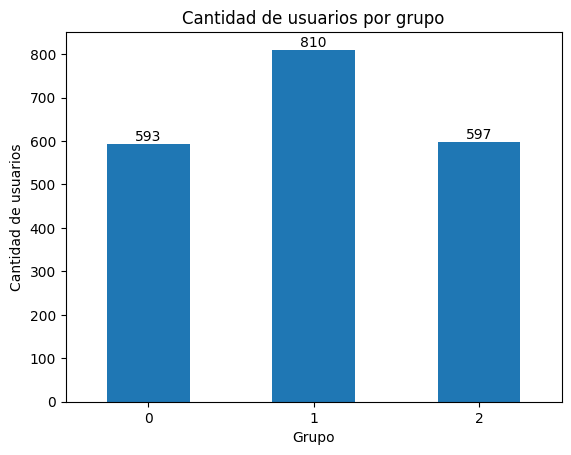

In [343]:
ax = conteo_grupos.plot(kind="bar")

plt.xlabel("Grupo")
plt.ylabel("Cantidad de usuarios")
plt.title("Cantidad de usuarios por grupo")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0])

plt.show()

### Interpretacion

El grupo 0 tiene 593 usuarios.

El grupo 1 tiene 810 usuarios y es el grupo con mayor cantidad.

El grupo 2 tiene 597 usuarios.

Los tres grupos tienen una cantidad suficiente de usuarios para poder
comparar sus caracteristicas.

## 6.5 Caracteristicas de cada grupo

Ahora se calculara el promedio de las variables de cada grupo para
conocer que caracteristicas los diferencian.

In [344]:
perfil_grupos = df_perfil_limpio.groupby("grupo")[
    [
        "frecuencia_sesiones",
        "tiempo_plataforma",
        "diversidad_categorias",
        "compras_mensuales",
        "gasto_mensual",
        "sensibilidad_descuento",
        "interaccion_recomendaciones",
        "productos_guardados",
        "resenas_realizadas",
        "devoluciones",
        "exploracion_novedades",
        "fidelidad"
    ]
].mean().round(2)

perfil_grupos

,frecuencia_sesiones,tiempo_plataforma,diversidad_categorias,compras_mensuales,gasto_mensual,sensibilidad_descuento,interaccion_recomendaciones,productos_guardados,resenas_realizadas,devoluciones,exploracion_novedades,fidelidad
grupo,,,,,,,,,,,,
0,13.41,336.23,4.50,2.20,153.07,52.31,25.18,6.03,1.92,0.67,87.39,60.61
1,22.72,331.94,2.92,3.11,254.52,71.30,8.98,5.76,1.97,0.65,49.12,67.08
2,5.93,333.08,3.04,0.83,77.11,55.06,8.95,6.16,2.00,0.72,49.16,39.51


## 6.6 Interpretacion de los grupos

### Grupo 0 - Clientes exploradores

Este grupo tiene 593 usuarios.

Presenta una alta interaccion con recomendaciones, con un promedio de 25.18.

Tambien tiene el valor mas alto de exploracion de novedades, con 87.39,
y una diversidad de categorias de aproximadamente 4.50.

Son usuarios que revisan diferentes productos y muestran interes por
las recomendaciones y productos nuevos.


### Grupo 1 - Clientes frecuentes de alto valor

Este grupo tiene 810 usuarios.

Tiene el mayor numero de sesiones, con un promedio de 22.72.

Tambien presenta la mayor cantidad de compras mensuales, con 3.11,
y el mayor gasto mensual, con 254.52.

Su fidelidad promedio es de 67.08, siendo la mas alta de los tres grupos.

Este grupo representa a los clientes mas activos y con mayor valor
para la empresa.


### Grupo 2 - Clientes ocasionales

Este grupo tiene 597 usuarios.

Tiene solamente 5.93 sesiones en promedio y realiza aproximadamente
0.83 compras por mes.

Su gasto mensual promedio es de 77.11 y su fidelidad es de 39.51.

Estos son los valores mas bajos de los tres grupos.

Este grupo representa a usuarios con menor actividad y menor frecuencia
de compra.

## 6.7 Decisiones para cada grupo

### Grupo 0 - Clientes exploradores

Se les pueden mostrar productos nuevos y recomendaciones personalizadas,
ya que tienen una alta interaccion con recomendaciones y novedades.


### Grupo 1 - Clientes frecuentes de alto valor

Se pueden ofrecer beneficios, promociones especiales y acciones para
mantener su fidelidad, ya que son los clientes que compran y gastan mas.


### Grupo 2 - Clientes ocasionales

Se pueden utilizar descuentos, promociones o recomendaciones para intentar
aumentar su actividad y motivarlos a realizar nuevas compras.

## 6.8 Conclusion

K-Means permitio encontrar 3 grupos diferentes de clientes.

El grupo 0 esta formado principalmente por usuarios que exploran productos
y utilizan recomendaciones.

El grupo 1 contiene a los usuarios mas activos, con mayor cantidad de
compras, mayor gasto y mayor fidelidad.

El grupo 2 contiene a usuarios menos activos, con menos compras,
menor gasto y menor fidelidad.

Los resultados permiten encontrar diferentes comportamientos entre
los usuarios.

Aunque la separacion entre los grupos no es muy alta, los grupos encontrados
permiten identificar diferentes perfiles y proponer acciones para cada uno.

# FASE 7. Sistema de recomendaciones

En esta fase se creara un sistema que recomiende productos a cada usuario.

Para esto se utilizaran las interacciones anteriores de los usuarios
y la informacion del catalogo de productos.

El sistema tomara en cuenta que categorias y subcategorias le interesan
mas al usuario, ademas de la popularidad y novedad de los productos.

## 7.1 Valor de las interacciones

Se asignara un valor diferente a cada tipo de interaccion.

Las acciones que muestran mayor interes tendran un valor mayor.

In [345]:
pesos_interaccion = {
    "vista": 1,
    "click": 2,
    "favorito": 3,
    "carrito": 4,
    "compra": 5
}

df_interacciones_limpio["peso"] = (
    df_interacciones_limpio["tipo_interaccion"]
    .map(pesos_interaccion)
)

In [346]:
print(
    df_interacciones_limpio[
        ["tipo_interaccion", "peso"]
    ].drop_duplicates().sort_values("peso")
)

   tipo_interaccion  peso
3             vista     1
0             click     2
5          favorito     3
35          carrito     4
41           compra     5


## 7.2 Gustos de los usuarios

Se calculara que categorias y subcategorias tienen mayor importancia
para cada usuario segun sus interacciones anteriores.

In [347]:
preferencia_categoria = (
    df_interacciones_limpio
    .groupby(["id_usuario", "categoria"])["peso"]
    .sum()
    .reset_index(name="puntaje_categoria")
)

preferencia_subcategoria = (
    df_interacciones_limpio
    .groupby(
        ["id_usuario", "categoria", "subcategoria"]
    )["peso"]
    .sum()
    .reset_index(name="puntaje_subcategoria")
)

In [348]:
preferencia_categoria[
    preferencia_categoria["id_usuario"] == 1001
].sort_values(
    "puntaje_categoria",
    ascending=False
)

,id_usuario,categoria,puntaje_categoria
2,1001,Hogar,11
4,1001,Tecnología,8
0,1001,Bienestar,5
1,1001,Deporte,5
3,1001,Moda,1


## 7.3 Creacion de recomendaciones

El sistema buscara productos con relacion a los gustos anteriores
del usuario.

No se recomendaran productos con los que el usuario ya tuvo una interaccion.

Para ordenar los productos se tomaran en cuenta:

- Categoria preferida.
- Subcategoria preferida.
- Popularidad.
- Nivel de novedad.

In [349]:
def recomendar_productos(id_usuario, cantidad=5):

    productos_vistos = set(
        df_interacciones_limpio[
            df_interacciones_limpio["id_usuario"] == id_usuario
        ]["id_producto"]
    )

    categorias_usuario = preferencia_categoria[
        preferencia_categoria["id_usuario"] == id_usuario
    ].copy()

    subcategorias_usuario = preferencia_subcategoria[
        preferencia_subcategoria["id_usuario"] == id_usuario
    ].copy()

    categorias_usuario["preferencia_categoria"] = (
        categorias_usuario["puntaje_categoria"] /
        categorias_usuario["puntaje_categoria"].max()
    )

    subcategorias_usuario["preferencia_subcategoria"] = (
        subcategorias_usuario["puntaje_subcategoria"] /
        subcategorias_usuario["puntaje_subcategoria"].max()
    )

    candidatos = df_productos_limpio[
        ~df_productos_limpio["id_producto"].isin(productos_vistos)
    ].copy()

    candidatos = candidatos.merge(
        categorias_usuario[
            ["categoria", "preferencia_categoria"]
        ],
        on="categoria",
        how="left"
    )

    candidatos = candidatos.merge(
        subcategorias_usuario[
            ["subcategoria", "preferencia_subcategoria"]
        ],
        on="subcategoria",
        how="left"
    )

    candidatos["preferencia_categoria"] = (
        candidatos["preferencia_categoria"].fillna(0)
    )

    candidatos["preferencia_subcategoria"] = (
        candidatos["preferencia_subcategoria"].fillna(0)
    )

    candidatos["puntaje"] = (
        0.50 * candidatos["preferencia_categoria"] +
        0.30 * candidatos["preferencia_subcategoria"] +
        0.15 * (candidatos["popularidad"] / 100) +
        0.05 * (candidatos["nivel_novedad"] / 100)
    )

    recomendaciones = candidatos.sort_values(
        "puntaje",
        ascending=False
    ).head(cantidad)

    return recomendaciones[
        [
            "id_producto",
            "categoria",
            "subcategoria",
            "precio",
            "popularidad",
            "nivel_novedad",
            "puntaje"
        ]
    ]

## 7.4 Top 5 de recomendaciones

Se probara el sistema utilizando al usuario 1001.

El sistema mostrara los 5 productos que tienen mayor relacion con
sus gustos y comportamiento anterior.

In [350]:
recomendaciones_1001 = recomendar_productos(1001, 5)

recomendaciones_1001.round(4)

,id_producto,categoria,subcategoria,precio,popularidad,nivel_novedad,puntaje
53,P056,Hogar,Iluminación,79.00,96.6,99.1,0.9944
119,P124,Hogar,Iluminación,74.48,95.5,43.9,0.9652
127,P132,Hogar,Iluminación,72.05,91.9,47.7,0.9617
131,P136,Hogar,Iluminación,262.65,84.7,58.7,0.9564
230,P241,Hogar,Iluminación,137.96,82.3,62.5,0.9547


Para el usuario 1001, los productos recomendados pertenecen principalmente
a la categoria Hogar y a la subcategoria Iluminacion.

Hogar es la categoria con mayor interes para este usuario segun sus
interacciones anteriores.

Tambien se tomaron en cuenta la popularidad y el nivel de novedad
de los productos.

Los productos recomendados no aparecen entre los productos con los que
el usuario ya tuvo una interaccion.

Por esta razon, las recomendaciones tienen relacion con el comportamiento
anterior del usuario y al mismo tiempo muestran productos nuevos.

In [351]:
id_usuario = 1002

recomendar_productos(id_usuario, 5).round(4)

,id_producto,categoria,subcategoria,precio,popularidad,nivel_novedad,puntaje
426,P439,Deporte,Outdoor,66.00,100.0,89.9,0.9950
369,P381,Deporte,Outdoor,87.97,92.9,99.2,0.9890
342,P354,Deporte,Outdoor,375.19,100.0,72.2,0.9861
132,P137,Deporte,Outdoor,72.41,93.4,83.2,0.9817
439,P452,Deporte,Outdoor,26.47,92.2,75.2,0.9759


### Motivo de las recomendaciones

Los cinco productos recomendados pertenecen a Hogar e Iluminacion,
que tienen una alta relacion con los intereses anteriores del usuario.

P056 tiene la mayor puntuacion porque combina una popularidad de 96.6
con un nivel de novedad de 99.1.

P124 y P132 tienen una popularidad alta, con 95.5 y 91.9 respectivamente.

P136 y P241 tambien pertenecen a la misma categoria y subcategoria
preferida, manteniendo buenos valores de popularidad y novedad.

Por esta razon, los cinco productos tienen relacion con los gustos
anteriores del usuario.

## 7.7 Conclusion del sistema de recomendaciones

El sistema permite generar un Top 5 de productos para cada usuario.

Las recomendaciones se realizan utilizando las categorias y subcategorias
con las que el usuario tuvo mayor interaccion.

Tambien se considera la popularidad y novedad de cada producto.

Este sistema puede ayudar a mostrar productos que tengan mayor relacion
con los intereses de cada cliente.

Como mejora futura se podria utilizar mas informacion de las compras,
valoraciones y comportamiento de usuarios con gustos parecidos.

# 8. Interpretacion final de resultados

## 8.1 Prediccion

El objetivo del modelo fue predecir si un usuario realizara una compra
durante los proximos 30 dias.

Se probaron Regresion Logistica, Arbol de Decision y Random Forest.

Al principio los modelos obtenian un Accuracy cercano al 70%, pero casi
no lograban identificar a los usuarios que si realizarian una compra.

Esto ocurria porque existian muchos mas usuarios que no compraban que
usuarios que si compraban.

Luego de ajustar este problema, la Regresion Logistica mejoro su Recall
hasta aproximadamente 0.50.

Esto significa que logro identificar correctamente alrededor de la mitad
de los usuarios que realmente realizarian una compra.

Las variables que mas ayudaron a realizar la prediccion fueron:

- compras_ultimos_6m
- dias_desde_ultima_compra
- gasto_promedio

Los resultados muestran que los usuarios que compraron mas anteriormente,
gastaron mas y realizaron una compra recientemente tienen una mayor
posibilidad de volver a comprar.

Aun asi, el modelo todavia comete varios errores y no deberia utilizarse
como la unica informacion para tomar una decision real.

## 8.2 Grupos de clientes

Se encontraron 3 grupos principales de usuarios utilizando K-Means.

### Grupo 0 - Clientes exploradores

Son usuarios que tienen una alta interaccion con recomendaciones y
muestran interes por productos nuevos y diferentes categorias.

Para este grupo se pueden mostrar nuevos productos y recomendaciones
personalizadas.


### Grupo 1 - Clientes frecuentes de alto valor

Son los usuarios con mayor cantidad de sesiones, compras, gasto y fidelidad.

Este grupo representa a los clientes mas importantes para la empresa.

Se pueden ofrecer promociones especiales, beneficios y acciones para
mantener su fidelidad.


### Grupo 2 - Clientes ocasionales

Son usuarios con menor cantidad de sesiones, compras, gasto y fidelidad.

Para este grupo se pueden utilizar descuentos, promociones y
recomendaciones que intenten aumentar su actividad.

## 8.3 Sistema de recomendaciones

El sistema permite generar un Top 5 de productos para cada usuario.

Para realizar las recomendaciones se utilizaron principalmente:

- Las categorias con las que interactuo el usuario.
- Las subcategorias que mostraron mayor interes.
- La popularidad de los productos.
- El nivel de novedad.

Tambien se dio mayor importancia a acciones como compras, carrito y
favoritos que a una simple vista.

Los productos con los que el usuario ya tuvo una interaccion fueron
excluidos para poder mostrar nuevas opciones.

Las recomendaciones obtenidas tienen relacion con los gustos anteriores
de cada usuario.

Como mejora futura se podria utilizar informacion de otros usuarios con
gustos parecidos, valoraciones y mayor cantidad de datos historicos.

# 9. Conclusion general

El proyecto permitio utilizar los datos de SmartLife para resolver
tres problemas diferentes.

Primero se desarrollo un modelo para predecir si un usuario realizara
una compra durante los proximos 30 dias.

Despues se encontraron tres tipos diferentes de clientes segun su
comportamiento.

Finalmente se desarrollo un sistema capaz de generar recomendaciones
personalizadas de productos.

Durante el desarrollo tambien se revisaron y limpiaron los datos,
eliminando filas repetidas, completando datos vacios y revisando valores
muy alejados del resto.

Los resultados muestran que los datos pueden ayudar a conocer mejor
a los clientes y apoyar la toma de decisiones.

El modelo de prediccion todavia puede mejorar, pero los grupos encontrados
y el sistema de recomendaciones permiten obtener informacion util sobre
el comportamiento de los usuarios.

# 10. Guardado de los datos limpios

Finalmente se guardaran los archivos despues de realizar la limpieza.

El archivo principal se guardara como dataset.csv para cumplir con
el archivo solicitado para la entrega.

In [352]:
dataset_final = df_prediccion_limpio.copy()

columnas_numericas_final = dataset_final.select_dtypes(include="number").columns
columnas_categoria_final = dataset_final.select_dtypes(exclude="number").columns

for columna in columnas_numericas_final:
    dataset_final[columna] = dataset_final[columna].fillna(
        dataset_final[columna].median()
    )

for columna in columnas_categoria_final:
    dataset_final[columna] = dataset_final[columna].fillna(
        dataset_final[columna].mode()[0]
    )

In [353]:
print("Filas:", dataset_final.shape[0])
print("Columnas:", dataset_final.shape[1])
print("Nulos:", dataset_final.isnull().sum().sum())
print("Duplicados:", dataset_final.duplicated().sum())

Filas: 2000
Columnas: 17
Nulos: 0
Duplicados: 0


In [354]:
import os

ruta_salida = "/content/drive/MyDrive/Proyecto_Final"

os.makedirs(ruta_salida, exist_ok=True)

print("Carpeta lista:", ruta_salida)


dataset_final.to_csv(
    ruta_salida + "/dataset.csv",
    index=False
)

df_perfil_limpio.to_csv(
    ruta_salida + "/perfil_comportamiento_limpio.csv",
    index=False
)

df_productos_limpio.to_csv(
    ruta_salida + "/catalogo_productos_limpio.csv",
    index=False
)

df_interacciones_limpio.to_csv(
    ruta_salida + "/interacciones_usuario_producto_limpio.csv",
    index=False
)

print("Archivos guardados correctamente")

Carpeta lista: /content/drive/MyDrive/Proyecto_Final
Archivos guardados correctamente


In [355]:
import os

os.listdir(ruta_salida)

['dataset.csv',
 'perfil_comportamiento_limpio.csv',
 'catalogo_productos_limpio.csv',
 'interacciones_usuario_producto_limpio.csv']

In [359]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/Proyecto_Final/dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [360]:
import shutil

shutil.make_archive(
    "/content/Proyecto_Final_Datasets",
    "zip",
    "/content/drive/MyDrive/Proyecto_Final"
)

'/content/Proyecto_Final_Datasets.zip'

In [361]:
from google.colab import files

files.download("/content/Proyecto_Final_Datasets.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>